In [1]:
USE_OPTUNA = True

# Main Orchestration

This notebook runs the ASM2d-TCN simulation model from the source package and persists the generated dataset and metadata under the repository data contract.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from src.models.simulation.asm2d_tcn_simulation import get_asm2d_tcn_matrices, load_asm2d_tcn_simulation_params
from src.utils.simulation import get_repo_root

repo_root = get_repo_root()
simulation_dir = repo_root / "data" / "asm2d-tcn" / "simulation"

dataset_candidates = {
    path.stem.removeprefix("data_"): path
    for path in simulation_dir.glob("data_*.csv")
}
metadata_candidates = {
    path.stem.removeprefix("metadata_"): path
    for path in simulation_dir.glob("metadata_*.json")
}

if not dataset_candidates:
    raise FileNotFoundError(f"No ASM2d-TCN datasets found in {simulation_dir}")
if not metadata_candidates:
    raise FileNotFoundError(f"No ASM2d-TCN metadata files found in {simulation_dir}")

shared_timestamps = sorted(set(dataset_candidates) & set(metadata_candidates))
if shared_timestamps:
    latest_timestamp = shared_timestamps[-1]
    latest_dataset_path = dataset_candidates[latest_timestamp]
    latest_metadata_path = metadata_candidates[latest_timestamp]
else:
    latest_dataset_path = max(dataset_candidates.values(), key=lambda path: path.stat().st_mtime)
    latest_metadata_path = max(metadata_candidates.values(), key=lambda path: path.stat().st_mtime)

dataset = pd.read_csv(latest_dataset_path)
metadata = json.loads(latest_metadata_path.read_text(encoding="utf-8"))
artifact_paths = {
    "dataset_csv": latest_dataset_path,
    "metadata_json": latest_metadata_path,
}

workbook_path = repo_root / "data" / "asm2d-tcn" / "asm2d_tcn_workbook.xlsx"
if not workbook_path.exists():
    raise FileNotFoundError(f"ASM2d-TCN workbook not found: {workbook_path}")

state_columns = list(metadata["state_columns"])
measured_output_columns = list(metadata["measured_output_columns"])

stoichiometric_frame = pd.read_excel(
    workbook_path,
    sheet_name="stoichiometric_matrix",
    engine="openpyxl",
)
composition_frame = pd.read_excel(
    workbook_path,
    sheet_name="composition_matrix",
    engine="openpyxl",
)

petersen_matrix = stoichiometric_frame.loc[:, state_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
composition_by_state = (
    composition_frame.loc[:, ["state_variable", *measured_output_columns]]
    .set_index("state_variable")
    .reindex(state_columns)
)
composition_matrix = (
    composition_by_state.loc[:, measured_output_columns]
    .T
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

matrix_source = str(workbook_path.relative_to(repo_root))
if np.isnan(petersen_matrix).any() or np.isnan(composition_matrix).any():
    matrix_bundle = get_asm2d_tcn_matrices(load_asm2d_tcn_simulation_params(repo_root))
    petersen_matrix = matrix_bundle["petersen_matrix"]
    composition_matrix = matrix_bundle["composition_matrix"]
    matrix_source = "runtime matrix bundle (workbook formulas unresolved)"

print(f"Loaded {len(dataset)} rows for {metadata['simulation_name']}.")
print(f"Dataset loaded from: {artifact_paths['dataset_csv']}")
print(f"Metadata loaded from: {artifact_paths['metadata_json']}")
print(f"Matrix source: {matrix_source}")
print(f"Petersen matrix shape: {petersen_matrix.shape}")
print(f"Composition matrix shape: {composition_matrix.shape}")

display(dataset.head())
display(pd.Series(metadata, name="value").to_frame())
display(pd.DataFrame(petersen_matrix, index=metadata["processes"], columns=state_columns))
display(pd.DataFrame(composition_matrix, index=measured_output_columns, columns=state_columns))

Loaded 10000 rows for asm2d_tcn_simulation.
Dataset loaded from: C:\Users\eselerio\projects\pibre-model\data\asm2d-tcn\simulation\data_20260330_024847.csv
Metadata loaded from: C:\Users\eselerio\projects\pibre-model\data\asm2d-tcn\simulation\metadata_20260330_024847.json
Matrix source: runtime matrix bundle (workbook formulas unresolved)
Petersen matrix shape: (28, 21)
Composition matrix shape: (6, 21)


,HRT,Aeration,In_S_A,In_S_F,In_S_I,In_S_N2,In_S_NH4,In_S_NO2,In_S_NO3,In_S_PO4,...,In_X_NOB,In_X_TSS,In_X_MeOH,In_X_MeP,Out_COD,Out_TN,Out_TKN,Out_TP,Out_TSS,Out_VSS
0,16.635779,2.441396,63.046704,90.220550,78.687834,1.394736,16.049626,2.926867,6.089118,14.577029,...,0.978629,388.410985,7.579973,9.097053,555.678020,50.365710,32.658337,33.044827,422.541437,356.848357
1,30.967794,2.109529,71.984084,144.541360,25.571097,0.933442,13.883562,0.462868,5.464392,13.916194,...,3.778639,255.493219,8.403181,3.748400,343.718748,36.592386,22.913018,29.943624,280.266159,237.875882
2,15.118503,0.561636,34.060878,66.132497,64.599640,0.279505,20.596053,0.022087,6.295395,12.637614,...,6.237491,292.601437,6.642953,6.710486,397.941176,37.115558,35.183335,32.196433,295.605893,242.432755
3,10.569363,1.892641,37.753804,54.333548,42.682291,1.706806,22.059398,0.174908,2.251071,6.697500,...,5.917695,333.320188,1.935261,6.012537,467.332598,45.903546,41.089729,18.652202,350.851130,317.162135
4,23.376587,0.853546,38.461721,80.963396,34.120967,1.260565,27.557942,0.262950,0.944047,17.390363,...,7.269518,384.463498,2.428360,3.671479,452.266376,53.187988,53.081237,34.920484,344.147692,310.844596


,value
simulation_name,asm2d_tcn_simulation
n_samples,10000
random_seed,42
dependent_columns,"[Out_COD, Out_TN, Out_TKN, Out_TP, Out_TSS, Ou..."
independent_columns,"[HRT, Aeration, In_S_A, In_S_F, In_S_I, In_S_N..."
identifier_columns,[]
ignored_columns,[]
dataset_file,data/asm2d-tcn/simulation/data_20260330_024847...
state_columns,"[S_A, S_F, S_I, S_N2, S_NH4, S_NO2, S_NO3, S_P..."
measured_output_columns,"[COD, TN, TKN, TP, TSS, VSS]"


,S_A,S_F,S_I,S_N2,S_NH4,S_NO2,S_NO3,S_PO4,S_ALK,S_O2,...,X_S,X_H,X_PAO,X_PP,X_PHA,X_AOB,X_NOB,X_TSS,X_MeOH,X_MeP
Aerobic hydrolysis,0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Anoxic hydrolysis (NO2),0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Anoxic hydrolysis (NO3),0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Anaerobic hydrolysis,0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Aerobic growth on S_F,0.0,-1.6,0.0,0.000000,-0.038000,0.000000,0.000000,-0.0040,-0.002843,-0.600000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Aerobic growth on S_A,-1.6,0.0,0.0,0.000000,-0.086000,0.000000,0.000000,-0.0200,-0.006788,-0.600000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_F (NO3 -> NO2),0.0,-1.6,0.0,0.000000,-0.038000,0.525000,-0.525000,-0.0040,-0.002843,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_F (NO2 -> N2),0.0,-1.6,0.0,0.348837,-0.038000,-0.348837,0.000000,-0.0040,0.022074,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_A (NO3 -> NO2),-1.6,0.0,0.0,0.000000,-0.086000,0.525000,-0.525000,-0.0200,-0.006788,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_A (NO2 -> N2),-1.6,0.0,0.0,0.348837,-0.086000,-0.348837,0.000000,-0.0200,0.018129,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00


,S_A,S_F,S_I,S_N2,S_NH4,S_NO2,S_NO3,S_PO4,S_ALK,S_O2,...,X_S,X_H,X_PAO,X_PP,X_PHA,X_AOB,X_NOB,X_TSS,X_MeOH,X_MeP
COD,1.0,1.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.00,1.000,1.000,0.0,1.00,1.000,1.000,0.0,0.0,0.000
TN,0.0,0.03,0.01,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.04,0.086,0.086,0.0,0.00,0.086,0.086,0.0,0.0,0.000
TKN,0.0,0.03,0.01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.04,0.086,0.086,0.0,0.00,0.086,0.086,0.0,0.0,0.000
TP,0.0,0.01,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.01,0.020,0.020,1.0,0.00,0.020,0.020,0.0,0.0,0.205
TSS,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.000,0.000,0.0,0.00,0.000,0.000,1.0,0.0,0.000
VSS,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.75,0.750,0.750,0.0,0.75,0.750,0.750,0.0,0.0,0.000


In [3]:
import numpy as np
from scipy.linalg import null_space

cobre_constraint_basis = null_space(petersen_matrix)
cobre_A_matrix = cobre_constraint_basis.T

cobre_A_matrix = np.round(cobre_A_matrix, 5)
cobre_A_matrix[np.abs(cobre_A_matrix) < 1e-10] = 0.0

for row_index in range(cobre_A_matrix.shape[0]):
    non_zero_entries = cobre_A_matrix[row_index, cobre_A_matrix[row_index, :] != 0]
    if len(non_zero_entries) > 0:
        cobre_A_matrix[row_index, :] = cobre_A_matrix[row_index, :] / non_zero_entries[0]

macroscopic_stoichiometric_matrix = petersen_matrix @ composition_matrix.T
measured_constraint_basis = null_space(macroscopic_stoichiometric_matrix)
A_matrix = measured_constraint_basis.T

A_matrix = np.round(A_matrix, 5)
A_matrix[np.abs(A_matrix) < 1e-10] = 0.0

for row_index in range(A_matrix.shape[0]):
    non_zero_entries = A_matrix[row_index, A_matrix[row_index, :] != 0]
    if len(non_zero_entries) > 0:
        A_matrix[row_index, :] = A_matrix[row_index, :] / non_zero_entries[0]

print(f"Fractional Petersen matrix shape: {petersen_matrix.shape}")
print(f"COBRE invariant matrix shape: {cobre_A_matrix.shape}")
print(f"Measured-space invariant matrix shape kept for downstream regressors: {A_matrix.shape}")
display(
    pd.DataFrame(
        cobre_A_matrix,
        index=[f"constraint_{index + 1}" for index in range(cobre_A_matrix.shape[0])],
        columns=metadata["state_columns"],
    )
)

Fractional Petersen matrix shape: (28, 21)
COBRE invariant matrix shape: (6, 21)
Measured-space invariant matrix shape kept for downstream regressors: (0, 6)


,S_A,S_F,S_I,S_N2,S_NH4,S_NO2,S_NO3,S_PO4,S_ALK,S_O2,...,X_S,X_H,X_PAO,X_PP,X_PHA,X_AOB,X_NOB,X_TSS,X_MeOH,X_MeP
constraint_1,-0.0,1.0,-122.115741,43.285494,43.180556,43.391975,43.391975,-29.893519,1.476852,-0.0,...,6.891975,8.584877,8.584877,-6.334877,4.367284,8.584877,8.584877,-7.279321,2.435185,-2.280864
constraint_2,0.0,1.0,41.259080,30.538741,30.934625,30.142857,30.142857,8.578692,-5.548426,0.0,...,-1.389831,0.099274,0.099274,-3.207022,-2.156174,0.099274,0.099274,3.593220,77.556901,55.619855
constraint_3,0.0,1.0,-17.963673,7.606458,9.781029,5.431887,5.431887,78.202825,-30.441978,0.0,...,-17.095863,-15.973764,-15.973764,-1.039354,-14.537841,-15.973764,-15.973764,24.229062,-13.890010,-1.048436
constraint_4,0.0,1.0,50.768730,34.358306,33.546145,35.171553,35.171553,-3.445168,11.373507,0.0,...,1.364821,2.915309,2.915309,-2.984799,0.017372,2.915309,2.915309,-0.029316,-52.864278,-38.073833
constraint_5,-0.0,1.0,0.197026,7.572491,11.695167,3.449814,3.449814,79.107807,-57.717472,-0.0,...,56.650558,57.769517,57.769517,316.583643,44.460967,57.769517,57.769517,-74.100372,-20.063197,23.252788
constraint_6,-0.0,1.0,-31.996269,-6.250000,-30.932836,18.432836,18.432836,107.679104,345.544776,-0.0,...,-13.630597,-12.731343,-12.731343,56.078358,-11.656716,-12.731343,-12.731343,19.425373,11.552239,26.917910


In [4]:
import pandas as pd

from src.utils.process import (
    build_cobre_supervised_dataset,
    build_measured_supervised_dataset,
    make_train_test_split,
    sample_dataset_fraction,
)
from src.utils.simulation import load_ml_orchestration_params

ml_orchestration_params = load_ml_orchestration_params()
ml_orchestration = ml_orchestration_params["hyperparameters"]

measured_dataset = build_measured_supervised_dataset(
    dataset,
    metadata,
    composition_matrix,
)
cobre_dataset = build_cobre_supervised_dataset(
    dataset,
    metadata,
    composition_matrix,
)
main_dataset_splits = make_train_test_split(
    measured_dataset,
    test_fraction=float(ml_orchestration["test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
cobre_dataset_splits = make_train_test_split(
    cobre_dataset,
    test_fraction=float(ml_orchestration["test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
optuna_dataset = sample_dataset_fraction(
    main_dataset_splits.train,
    fraction=float(ml_orchestration["optuna_dataset_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
tuning_dataset_splits = make_train_test_split(
    optuna_dataset,
    test_fraction=float(ml_orchestration["optuna_test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)

split_sizes = {
    "train": len(main_dataset_splits.train.features),
    "test": len(main_dataset_splits.test.features),
    "optuna_dataset": len(optuna_dataset.features),
    "optuna_train": len(tuning_dataset_splits.train.features),
    "optuna_test": len(tuning_dataset_splits.test.features),
}
cobre_split_sizes = {
    "train": len(cobre_dataset_splits.train.features),
    "test": len(cobre_dataset_splits.test.features),
    "fractional_features": len(cobre_dataset.features.columns),
    "measured_targets": len(cobre_dataset.targets.columns),
    "fractional_constraints": len(cobre_dataset.constraint_reference.columns),
}
split_alignment_ok = (
    main_dataset_splits.train.features.index.equals(cobre_dataset_splits.train.features.index)
    and main_dataset_splits.test.features.index.equals(cobre_dataset_splits.test.features.index)
)

print("Notebook-managed ML orchestration is ready.")
print(f"Measured-space split sizes: train={split_sizes['train']}, test={split_sizes['test']}")
print(
    "COBRE split sizes: "
    f"train={cobre_split_sizes['train']}, test={cobre_split_sizes['test']}, "
    f"fractional_features={cobre_split_sizes['fractional_features']}, "
    f"measured_targets={cobre_split_sizes['measured_targets']}, "
    f"fractional_constraints={cobre_split_sizes['fractional_constraints']}"
)
print(f"Measured and COBRE splits aligned: {split_alignment_ok}")
print(
    "Optuna subset sizes: "
    f"dataset={split_sizes['optuna_dataset']}, train={split_sizes['optuna_train']}, test={split_sizes['optuna_test']}"
)

display(pd.DataFrame([ml_orchestration]))
display(pd.DataFrame([split_sizes]))
display(pd.DataFrame([cobre_split_sizes]))

Notebook-managed ML orchestration is ready.
Measured-space split sizes: train=8000, test=2000
COBRE split sizes: train=8000, test=2000, fractional_features=23, measured_targets=6, fractional_constraints=21
Measured and COBRE splits aligned: True
Optuna subset sizes: dataset=4000, train=3200, test=800


,random_seed,test_fraction,optuna_dataset_fraction,optuna_test_fraction,tuning_epochs,n_trials,timeout_seconds
0,42,0.2,0.5,0.2,500,30,None


,train,test,optuna_dataset,optuna_train,optuna_test
0,8000,2000,4000,3200,800


,train,test,fractional_features,measured_targets,fractional_constraints
0,8000,2000,23,6,21


## COBRE

This section now follows the strict fractional-space COBRE formulation. The notebook passes operational variables and influent ASM1 fractions into the bilinear model, derives the invariant matrix from the Petersen null space, and collapses the projected fractional prediction into the measured composite space with the composition matrix.

COBRE still uses a closed-form projected OLS solve with `ols_backend="numpy_lstsq"`, so there is no Optuna tuning branch for this model.

In [5]:
import pandas as pd

from src.models.ml import load_cobre_params, run_cobre_pipeline

cobre_params = load_cobre_params()
cobre_hyperparameters = dict(cobre_params["training_defaults"])

cobre_result = run_cobre_pipeline(
    cobre_dataset_splits.train,
    cobre_dataset_splits.test,
    cobre_A_matrix,
    composition_matrix=composition_matrix,
    model_params=cobre_params,
    model_hyperparameters=cobre_hyperparameters,
    persist_artifacts=True,
)

print("COBRE training complete.")
print(f"Operational inputs: {', '.join(metadata['operational_columns'])}")
print(f"Fractional influent states: {', '.join(metadata['state_columns'])}")
print(f"Measured-output targets: {', '.join(metadata['measured_output_columns'])}")
print(f"COBRE split sizes: {cobre_split_sizes}")
print(f"Saved model bundle: {cobre_result['artifact_paths']['model_bundle']}")
print(f"Saved metrics summary: {cobre_result['artifact_paths']['metrics']}")

display(pd.DataFrame([cobre_result["best_hyperparameters"]]))
display(pd.DataFrame([cobre_split_sizes]))
display(pd.Series(cobre_result["artifact_paths"], name="path").to_frame())
display(
    pd.DataFrame(
        cobre_result["model_bundle"]["collapse_operator"],
        index=metadata["measured_output_columns"],
        columns=metadata["state_columns"],
    )
)
display(
    pd.DataFrame(
        cobre_result["model_bundle"]["pass_through_operator"],
        index=metadata["measured_output_columns"],
        columns=metadata["state_columns"],
    )
)
display(cobre_result["train_report"]["aggregate_metrics"])
display(cobre_result["test_report"]["aggregate_metrics"])
display(cobre_result["test_report"]["per_target_metrics"])
display(cobre_result["test_report"]["constraint_residuals"].describe().T)

c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
                                                                                                               

COBRE training complete.
Operational inputs: HRT, Aeration
Fractional influent states: S_A, S_F, S_I, S_N2, S_NH4, S_NO2, S_NO3, S_PO4, S_ALK, S_O2, X_I, X_S, X_H, X_PAO, X_PP, X_PHA, X_AOB, X_NOB, X_TSS, X_MeOH, X_MeP
Measured-output targets: COD, TN, TKN, TP, TSS, VSS
COBRE split sizes: {'train': 8000, 'test': 2000, 'fractional_features': 23, 'measured_targets': 6, 'fractional_constraints': 21}
Saved model bundle: C:\Users\eselerio\projects\pibre-model\results\cobre\model_20260330_042543.pkl
Saved metrics summary: C:\Users\eselerio\projects\pibre-model\results\cobre\metrics_20260330_042543.json


,objective,solver,ols_backend,include_bias_term,lstsq_rcond
0,projected_ols,multivariate_lstsq,numpy_lstsq,True,None


,train,test,fractional_features,measured_targets,fractional_constraints
0,8000,2000,23,6,21


,path
model_bundle,C:\Users\eselerio\projects\pibre-model\results...
metrics,C:\Users\eselerio\projects\pibre-model\results...
optuna,None


...

,S_A,S_F,S_I,S_N2,S_NH4,S_NO2,S_NO3,S_PO4,S_ALK,S_O2,...,X_S,X_H,X_PAO,X_PP,X_PHA,X_AOB,X_NOB,X_TSS,X_MeOH,X_MeP
COD,0.0,-0.005618,1.000010e+00,0.071747,7.386858e-02,6.962773e-02,6.962773e-02,-0.776772,-2.972918e-02,0.0,...,0.373419,0.368943,0.368943,0.851568,0.302667,0.368943,0.368943,-0.504432,0.005949,-0.008405
TN,0.0,0.022425,9.999294e-03,0.751174,7.499522e-01,7.524140e-01,7.524140e-01,-0.011420,1.714198e-02,0.0,...,0.035435,0.069890,0.069890,0.012837,0.004402,0.069890,0.069890,-0.007346,0.000042,-0.000063
TKN,0.0,0.007319,9.998284e-03,0.255983,2.623715e-01,2.496015e-01,2.496015e-01,-0.033117,-8.941728e-02,0.0,...,0.026914,0.038333,0.038333,0.037373,0.013630,0.038333,0.038333,-0.022719,0.000360,-0.000514
TP,0.0,0.009997,1.366014e-10,0.000002,1.595941e-09,-8.101553e-08,-8.101553e-08,0.999975,-7.810981e-07,0.0,...,0.010003,0.019995,0.019995,0.999980,0.000003,0.019995,0.019995,-0.000009,-0.000155,0.205218
TSS,0.0,0.001920,1.119093e-06,0.007338,6.989314e-03,7.686329e-03,7.686329e-03,0.169935,4.881300e-03,0.0,...,-0.075407,-0.073368,-0.073368,-0.163244,-0.061922,-0.073368,-0.073368,0.103201,-0.002281,0.003220
VSS,0.0,-0.004445,6.432193e-06,0.048131,4.970897e-02,4.655582e-02,4.655582e-02,-0.588628,-2.208879e-02,0.0,...,0.280858,0.277177,0.277177,0.637287,0.227864,0.277177,0.277177,-0.379765,0.004849,-0.006849


,prediction_type,R2,MSE,RMSE,MAE,MAPE,constraint_mean_l2,constraint_max_l2,constraint_mean_abs,constraint_max_abs
0,raw,-4.185956,847.010912,29.103452,23.122104,0.361501,6.099038e+04,9.395842e+04,1.417502e+04,9.289603e+04
1,projected,0.974560,42.156773,6.492825,3.636836,0.026102,4.927790e-11,1.271684e-10,1.440943e-11,1.164153e-10


,prediction_type,R2,MSE,RMSE,MAE,MAPE,constraint_mean_l2,constraint_max_l2,constraint_mean_abs,constraint_max_abs
0,raw,-4.152290,841.682477,29.011764,23.049137,0.362109,5.991861e+04,9.374183e+04,1.396117e+04,9.256500e+04
1,projected,0.971038,44.730533,6.688089,3.805919,0.027992,4.842017e-11,1.218969e-10,1.412114e-11,1.164153e-10


,target,raw_R2,raw_MSE,raw_RMSE,raw_MAE,raw_MAPE,projected_R2,projected_MSE,projected_RMSE,projected_MAE,projected_MAPE
0,Out_COD,0.823203,1169.834982,34.202850,27.635634,0.065344,0.984107,105.159596,10.254735,7.267705,0.017392
1,Out_TN,-12.995824,2384.913643,48.835578,47.792308,0.848492,0.982046,3.059375,1.749107,1.339319,0.025290
2,Out_TKN,0.757421,54.188820,7.361306,5.694948,0.151282,0.912655,19.511614,4.417195,3.017675,0.081007
3,Out_TP,-15.260893,796.870505,28.228895,27.335341,0.998340,0.997525,0.121297,0.348278,0.118039,0.005518
4,Out_TSS,0.954903,132.186006,11.497217,9.114709,0.029005,0.973221,78.491593,8.859548,5.958266,0.019347
5,Out_VSS,0.807452,512.100904,22.629647,20.721879,0.080192,0.976673,62.039725,7.876530,5.134509,0.019396


,count,mean,std,min,25%,50%,75%,max
raw_constraint_l2,2000.0,5.991861e+04,1.822054e+04,2.889689e+04,4.371697e+04,5.940236e+04,7.573065e+04,9.374183e+04
projected_constraint_l2,2000.0,4.842017e-11,1.936333e-11,1.064536e-11,3.340962e-11,4.448628e-11,5.912546e-11,1.218969e-10


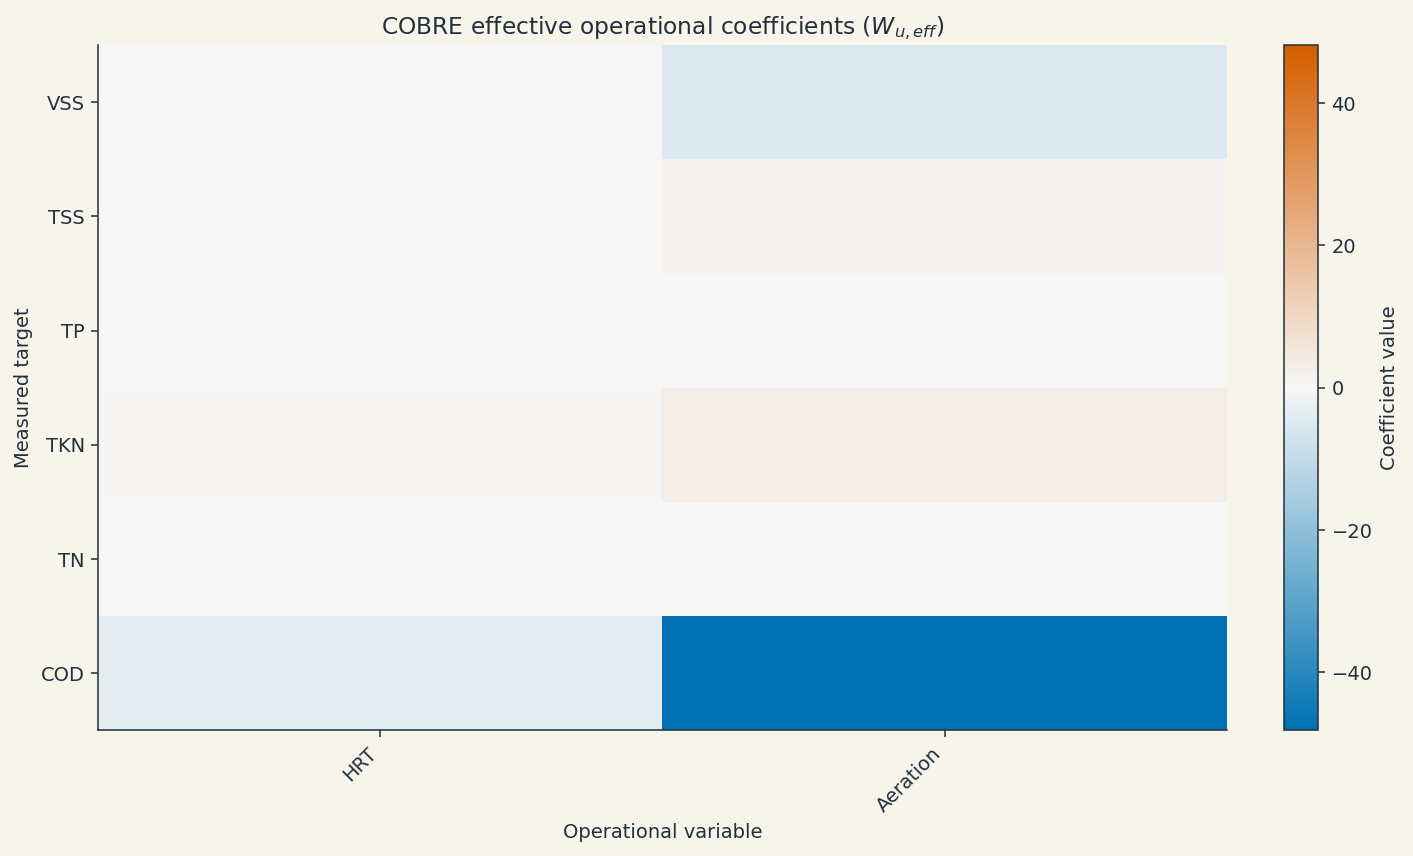

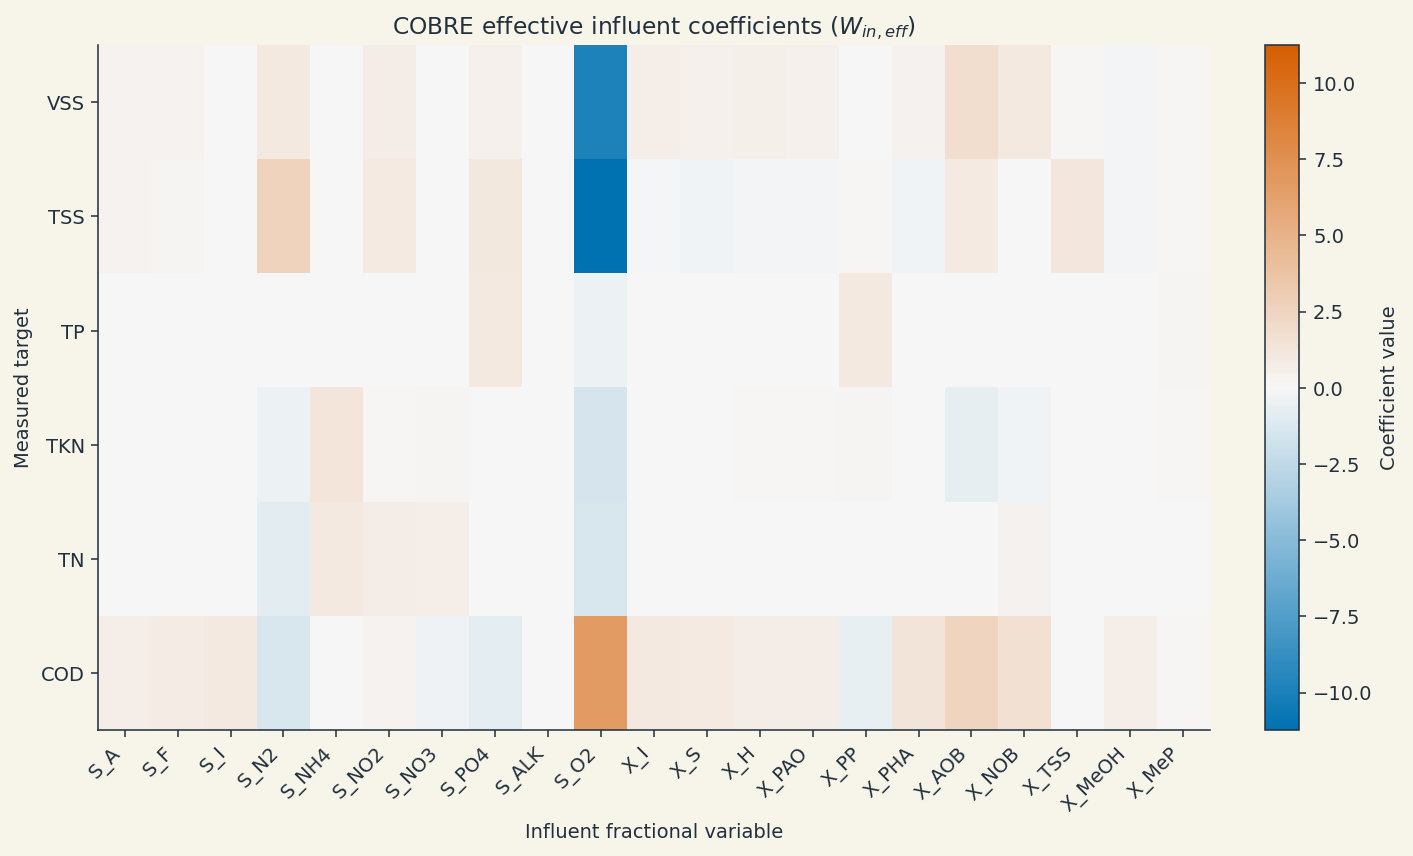

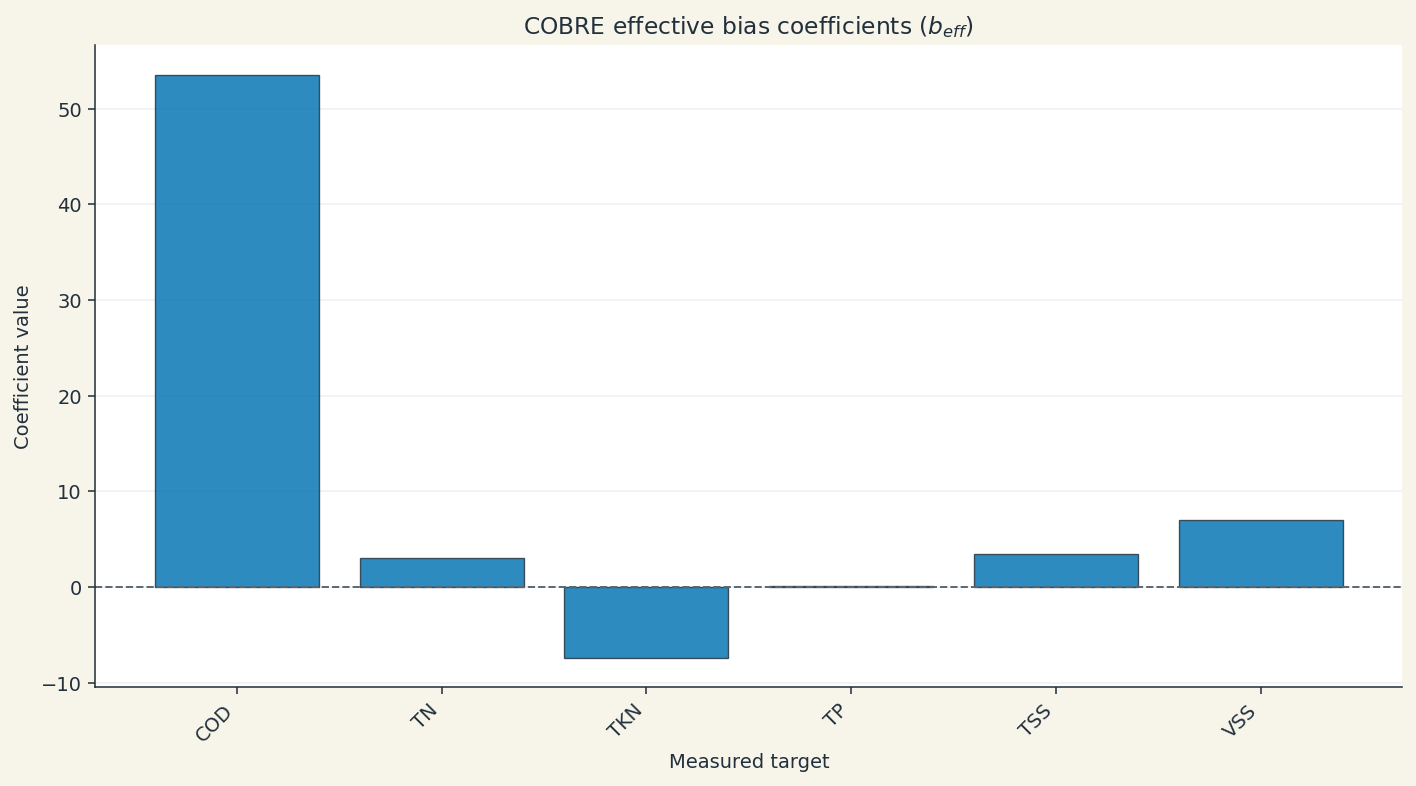

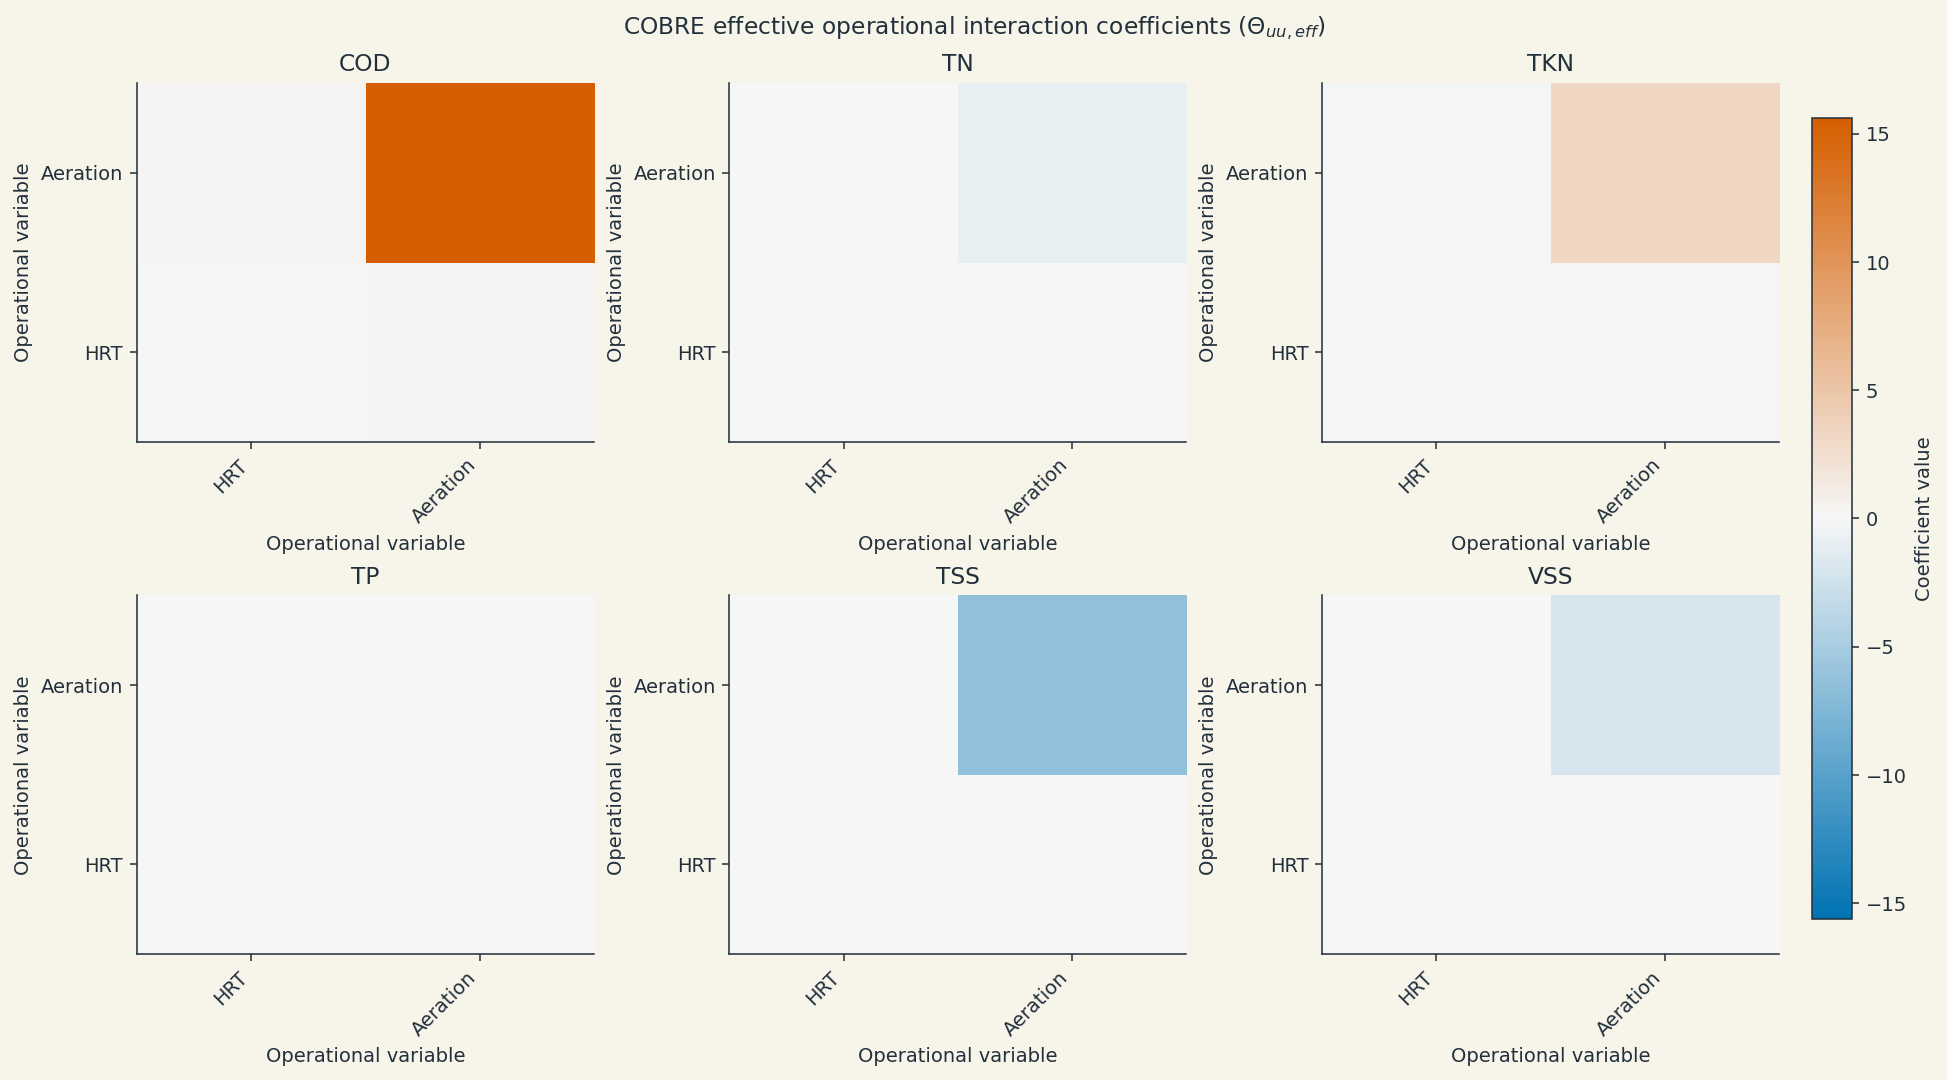

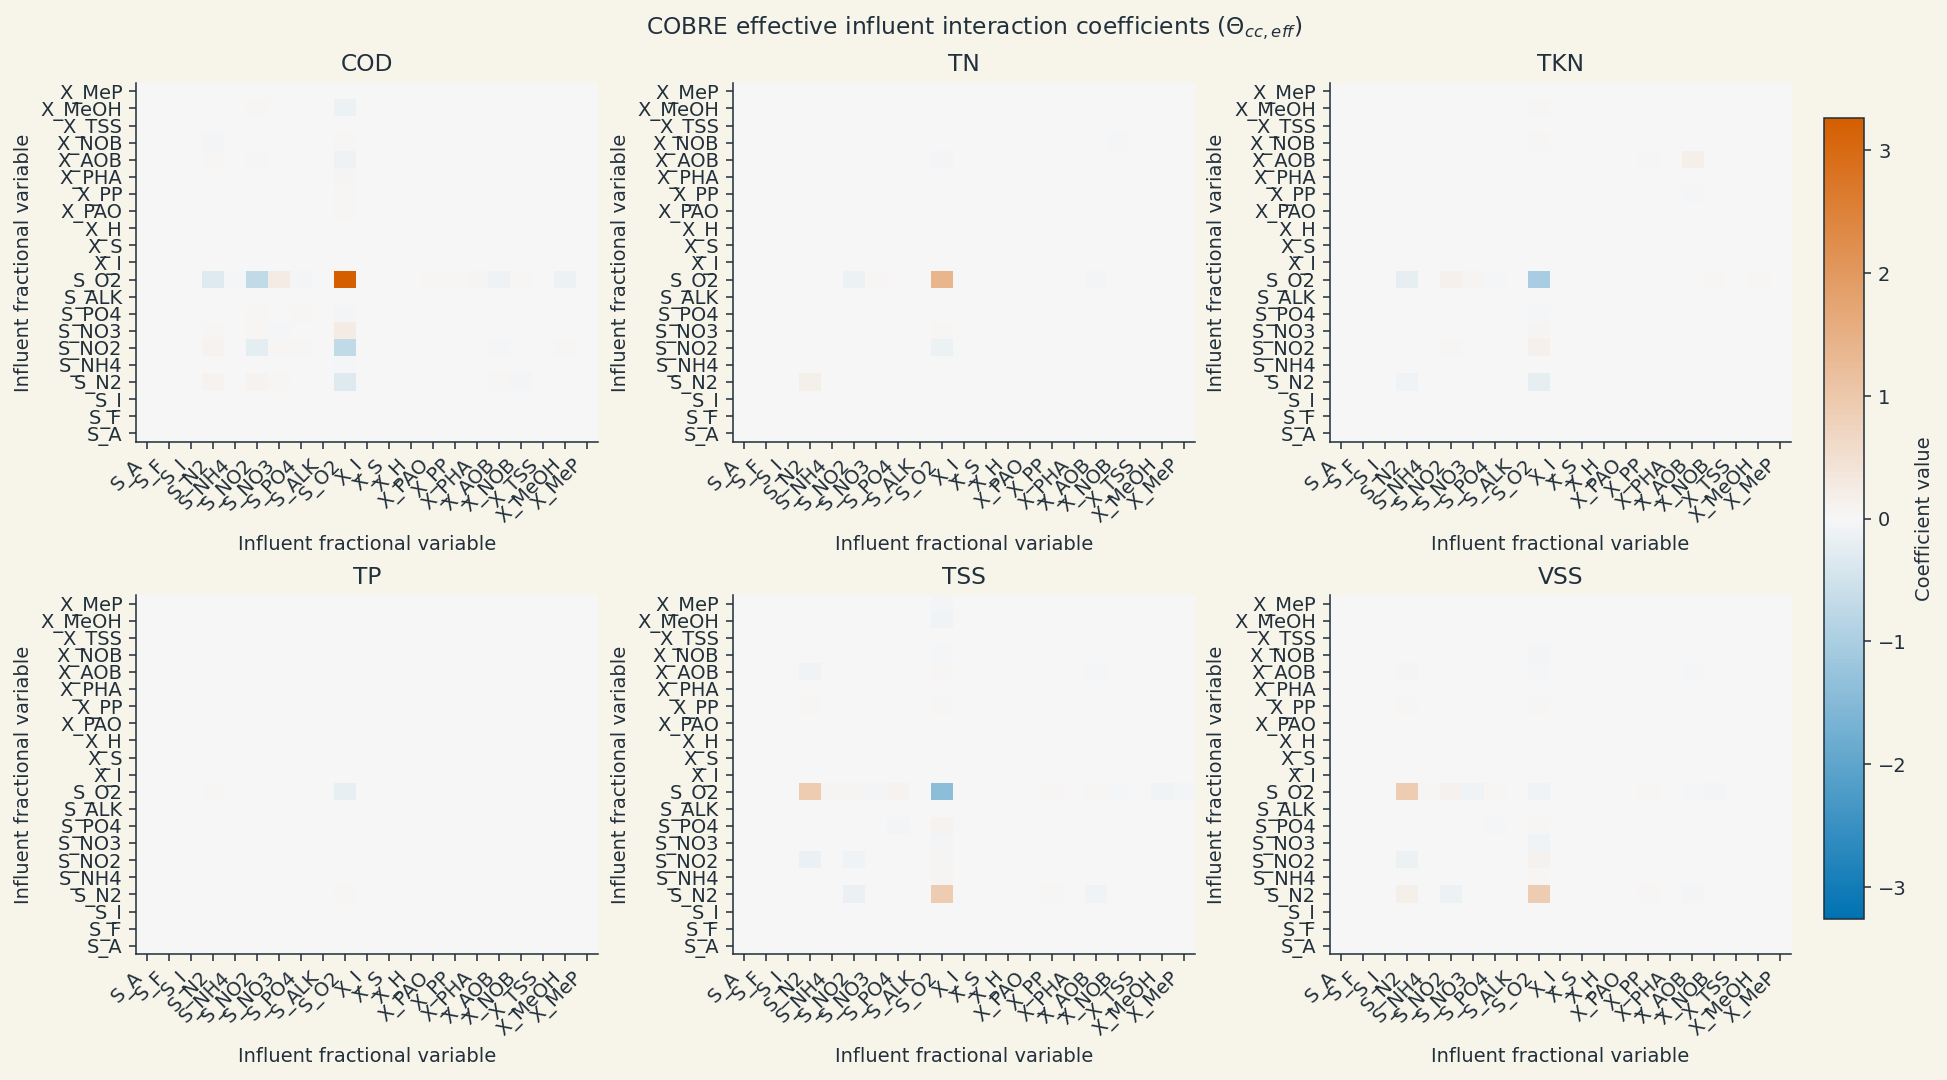

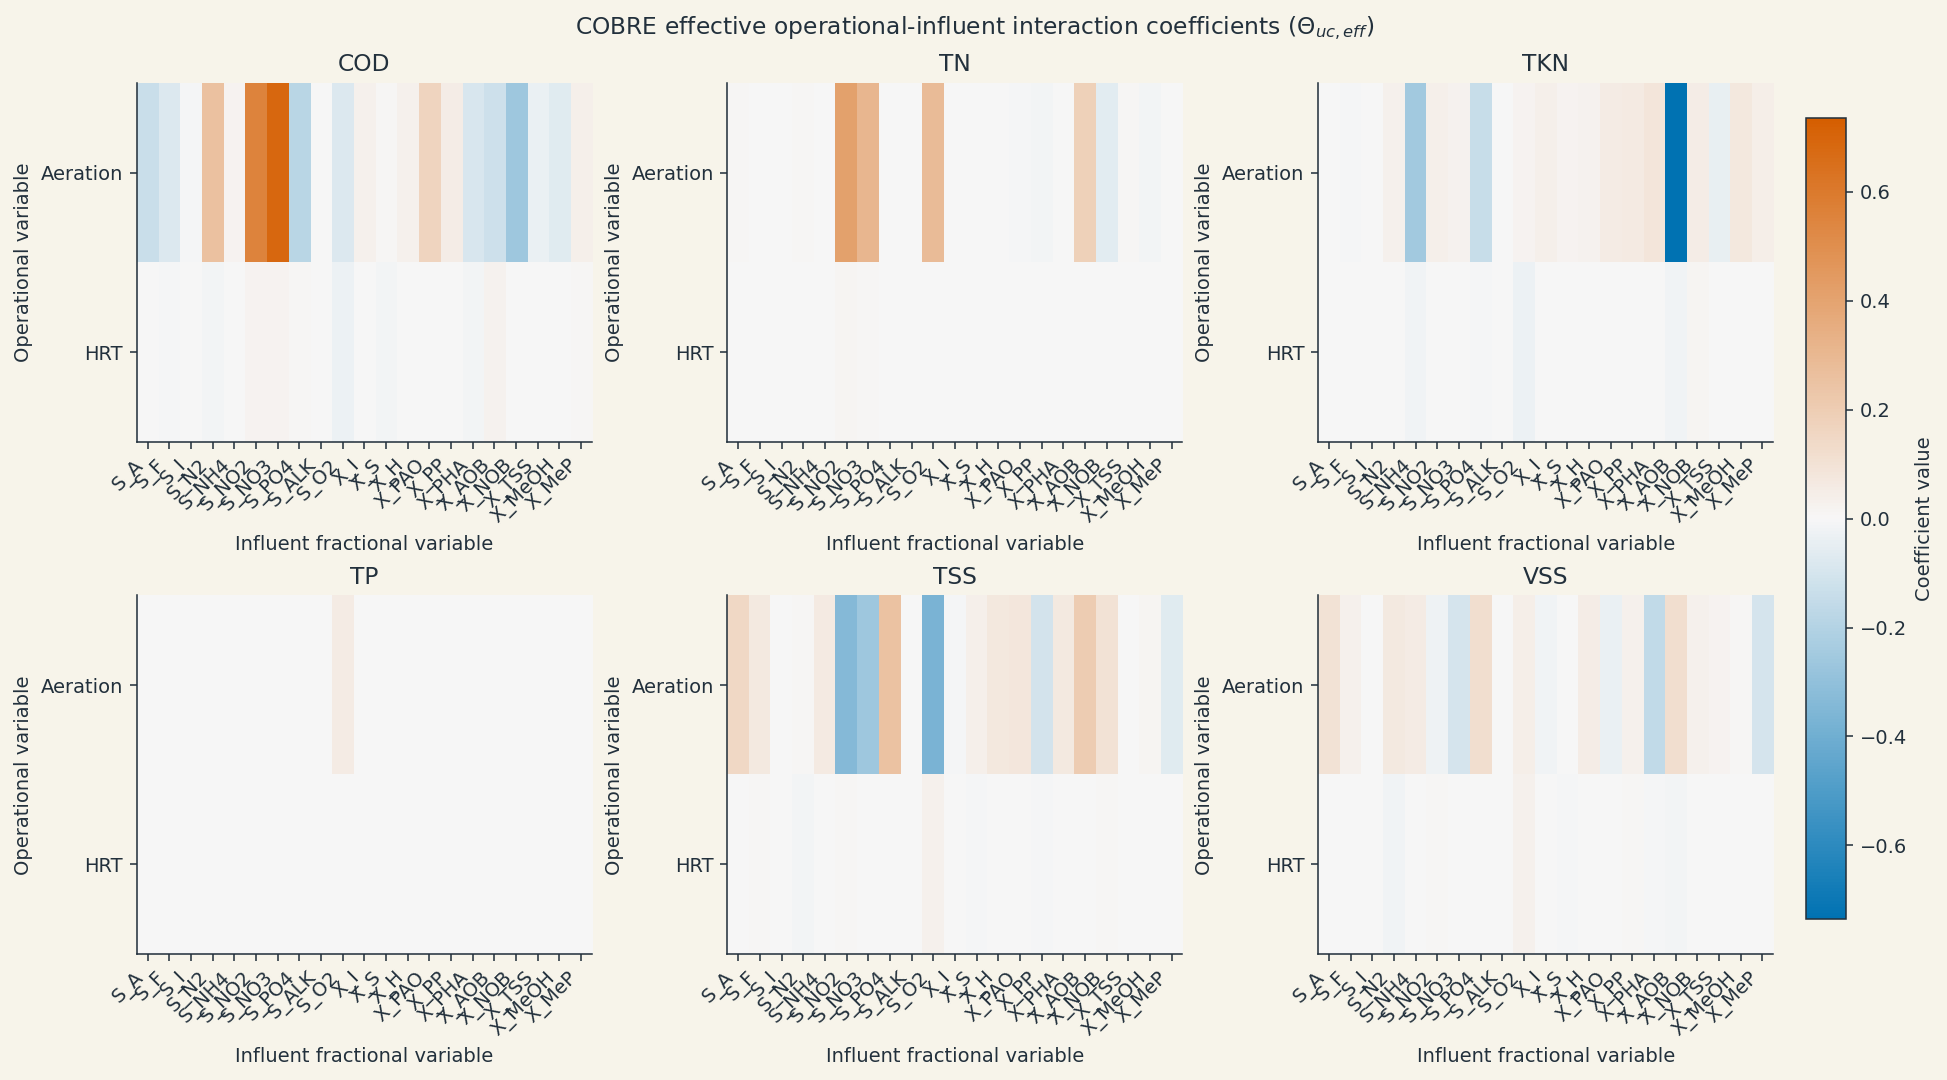

In [6]:
import matplotlib.pyplot as plt

from src.utils.plot import (
    plot_coefficient_bar_chart,
    plot_coefficient_heatmap,
    plot_coefficient_tensor_heatmaps,
)

effective_coefficients = cobre_result["model_bundle"]["effective_coefficients"]
measured_targets = list(metadata["measured_output_columns"])
operational_variables = list(metadata["operational_columns"])
influent_fractional_variables = list(metadata["state_columns"])

figure, _ = plot_coefficient_heatmap(
    effective_coefficients["W_u"],
    row_labels=measured_targets,
    column_labels=operational_variables,
    title=r"COBRE effective operational coefficients ($W_{u,eff}$)",
    x_label="Operational variable",
    y_label="Measured target",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_heatmap(
    effective_coefficients["W_in"],
    row_labels=measured_targets,
    column_labels=influent_fractional_variables,
    title=r"COBRE effective influent coefficients ($W_{in,eff}$)",
    x_label="Influent fractional variable",
    y_label="Measured target",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_bar_chart(
    effective_coefficients["b"],
    labels=measured_targets,
    title=r"COBRE effective bias coefficients ($b_{eff}$)",
    x_label="Measured target",
    y_label="Coefficient value",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_tensor_heatmaps(
    effective_coefficients["Theta_uu"],
    target_labels=measured_targets,
    row_labels=operational_variables,
    column_labels=operational_variables,
    title=r"COBRE effective operational interaction coefficients ($\Theta_{uu,eff}$)",
    x_label="Operational variable",
    y_label="Operational variable",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_tensor_heatmaps(
    effective_coefficients["Theta_cc"],
    target_labels=measured_targets,
    row_labels=influent_fractional_variables,
    column_labels=influent_fractional_variables,
    title=r"COBRE effective influent interaction coefficients ($\Theta_{cc,eff}$)",
    x_label="Influent fractional variable",
    y_label="Influent fractional variable",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_tensor_heatmaps(
    effective_coefficients["Theta_uc"],
    target_labels=measured_targets,
    row_labels=operational_variables,
    column_labels=influent_fractional_variables,
    title=r"COBRE effective operational-influent interaction coefficients ($\Theta_{uc,eff}$)",
    x_label="Influent fractional variable",
    y_label="Operational variable",
)
display(figure)
plt.close(figure)

## COBRE Response Surface

This block fixes the influent fractional states to a common profile and then evaluates the trained COBRE model over an extended HRT-Aeration grid. By default the fixed influent profile uses the midpoint of each configured influent-state range, and the operational grid extends 50% beyond the original training domain while clipping the lower HRT and Aeration bounds at zero so the operating points remain physically valid.

Override any of the defaults by defining `cobre_response_surface_overrides = {...}` before running the next cell.

COBRE response-surface analysis complete.
Fixed influent profile strategy: midpoint
Extended HRT range: -9.000 to 51.000
Extended Aeration range: -0.500 to 3.500


,grid_points_per_axis,contour_levels,operational_extension_fraction,fixed_influent_profile
0,49,18,0.5,midpoint


,value
S_A,42.50
S_F,100.00
S_I,50.00
S_N2,1.00
S_NH4,33.50
S_NO2,1.50
S_NO3,4.00
S_PO4,10.00
S_ALK,170.00
S_O2,0.25


,HRT,Aeration,In_S_A,In_S_F,In_S_I,In_S_N2,In_S_NH4,In_S_NO2,In_S_NO3,In_S_PO4,...,ConstraintReference_X_NOB,ConstraintReference_X_TSS,ConstraintReference_X_MeOH,ConstraintReference_X_MeP,Projected_Out_COD,Projected_Out_TN,Projected_Out_TKN,Projected_Out_TP,Projected_Out_TSS,Projected_Out_VSS
0,-9.00,-0.5,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,4.25,0.0,6.0,6.0,735.499212,57.607415,91.451696,30.279959,-6.034999,231.434139
1,-7.75,-0.5,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,4.25,0.0,6.0,6.0,723.422224,57.409652,92.153821,30.301627,-5.911633,228.976835
2,-6.50,-0.5,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,4.25,0.0,6.0,6.0,711.642968,57.215535,92.849371,30.322900,-5.763870,226.564432
3,-5.25,-0.5,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,4.25,0.0,6.0,6.0,700.161441,57.025065,93.538345,30.343777,-5.591708,224.196930
4,-4.00,-0.5,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,4.25,0.0,6.0,6.0,688.977646,56.838241,94.220744,30.364260,-5.395148,221.874328


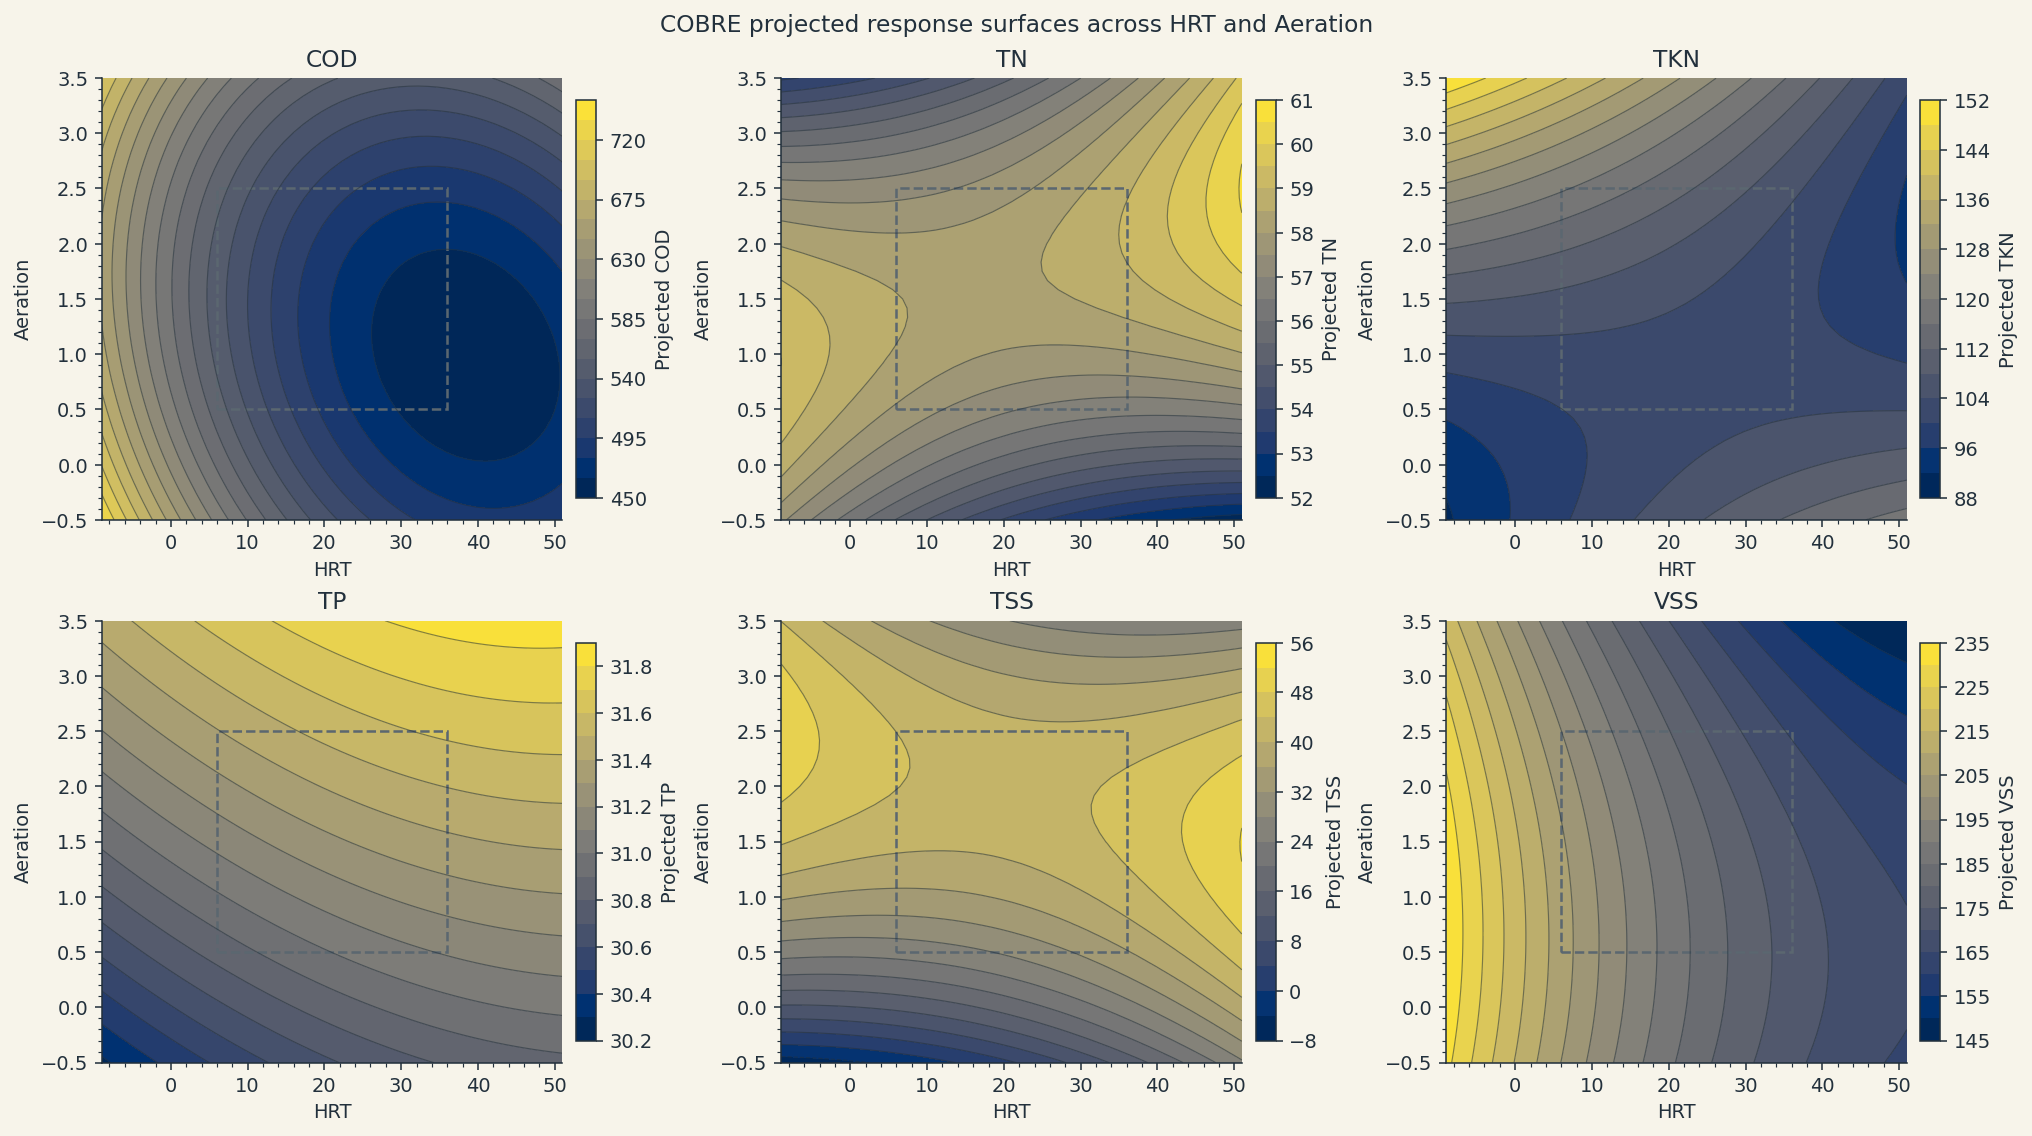

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

from src.utils.analysis import (
    build_cobre_response_surface_prediction_data,
    load_cobre_response_surface_defaults,
    )
from src.utils.plot import plot_response_surface_contours

cobre_response_surface_defaults = load_cobre_response_surface_defaults()
cobre_response_surface_overrides = dict(globals().get("cobre_response_surface_overrides", {}))
cobre_response_surface_config = {
    **cobre_response_surface_defaults,
    **cobre_response_surface_overrides,
}

cobre_model_path = cobre_result["artifact_paths"]["model_bundle"]
if cobre_model_path is None:
    raise ValueError("COBRE model bundle path is required to generate the response-surface plot.")

cobre_response_surface_result = build_cobre_response_surface_prediction_data(
    cobre_model_path,
    metadata=metadata,
    grid_points_per_axis=int(cobre_response_surface_config["grid_points_per_axis"]),
    operational_extension_fraction=float(
        cobre_response_surface_config["operational_extension_fraction"]
    ),
    fixed_influent_profile=cobre_response_surface_config["fixed_influent_profile"],
)

print("COBRE response-surface analysis complete.")
print(
    "Fixed influent profile strategy: "
    f"{cobre_response_surface_result['response_surface_config']['fixed_influent_profile']}"
)
print(
    "Extended HRT range: "
    f"{cobre_response_surface_result['extended_domain']['HRT']['min']:.3f} to "
    f"{cobre_response_surface_result['extended_domain']['HRT']['max']:.3f}"
)
print(
    "Extended Aeration range: "
    f"{cobre_response_surface_result['extended_domain']['Aeration']['min']:.3f} to "
    f"{cobre_response_surface_result['extended_domain']['Aeration']['max']:.3f}"
)

display(pd.DataFrame([cobre_response_surface_config]))
display(cobre_response_surface_result["fixed_influent_profile"].to_frame())
display(cobre_response_surface_result["prediction_table"].head())

figure, _ = plot_response_surface_contours(
    cobre_response_surface_result["operational_meshes"]["HRT"],
    cobre_response_surface_result["operational_meshes"]["Aeration"],
    cobre_response_surface_result["per_target_surfaces"],
    title="COBRE projected response surfaces across HRT and Aeration",
    x_label="HRT",
    y_label="Aeration",
    training_domain=cobre_response_surface_result["training_domain"],
    contour_levels=int(cobre_response_surface_config["contour_levels"]),
)
display(figure)
plt.close(figure)

## Additional Measured-Space Regressors

The notebook now owns the main train-test split and the optional Optuna subset used for hyperparameter optimization. Run the next cell to register the available measured-space regressors, then call `run_classical_regressor(...)` with `use_optuna=True` to tune on the notebook-managed subset or `use_optuna=False` to train with each model's `training_defaults`.

In [ ]:
import pandas as pd

from src.models.ml import (
    load_adaboost_regressor_params,
    load_catboost_regressor_params,
    load_lightgbm_regressor_params,
    load_random_forest_regressor_params,
    load_svr_regressor_params,
    load_xgboost_regressor_params,
    run_adaboost_regressor_pipeline,
    run_catboost_regressor_pipeline,
    run_lightgbm_regressor_pipeline,
    run_random_forest_regressor_pipeline,
    run_svr_regressor_pipeline,
    run_xgboost_regressor_pipeline,
)
from src.models.ml.adaboost_regressor import build_adaboost_regressor_model
from src.models.ml.catboost_regressor import build_catboost_regressor_model
from src.models.ml.lightgbm_regressor import build_lightgbm_regressor_model
from src.models.ml.random_forest_regressor import build_random_forest_regressor_model
from src.models.ml.svr_regressor import build_svr_regressor_model
from src.models.ml.xgboost_regressor import build_xgboost_regressor_model
from src.utils.train import tune_tabular_regressor_hyperparameters

classical_regressor_specs = {
    "xgboost_regressor": {
        "load_params": load_xgboost_regressor_params,
        "build_model": build_xgboost_regressor_model,
        "runner": run_xgboost_regressor_pipeline,
    },
    "lightgbm_regressor": {
        "load_params": load_lightgbm_regressor_params,
        "build_model": build_lightgbm_regressor_model,
        "runner": run_lightgbm_regressor_pipeline,
    },
    "catboost_regressor": {
        "load_params": load_catboost_regressor_params,
        "build_model": build_catboost_regressor_model,
        "runner": run_catboost_regressor_pipeline,
    },
    "adaboost_regressor": {
        "load_params": load_adaboost_regressor_params,
        "build_model": build_adaboost_regressor_model,
        "runner": run_adaboost_regressor_pipeline,
    },
    "random_forest_regressor": {
        "load_params": load_random_forest_regressor_params,
        "build_model": build_random_forest_regressor_model,
        "runner": run_random_forest_regressor_pipeline,
    },
    "svr_regressor": {
        "load_params": load_svr_regressor_params,
        "build_model": build_svr_regressor_model,
        "runner": run_svr_regressor_pipeline,
    },
}

def run_classical_regressor(
    model_name: str,
    *,
    use_optuna: bool = True,
    persist_artifacts: bool = True,
):
    spec = classical_regressor_specs[model_name]
    model_params = spec["load_params"]()
    selected_hyperparameters = dict(model_params["training_defaults"])
    optuna_summary = None

    if use_optuna:
        selected_hyperparameters, optuna_summary = tune_tabular_regressor_hyperparameters(
            model_name,
            spec["build_model"],
            tuning_dataset_splits.train,
            tuning_dataset_splits.test,
            A_matrix=A_matrix,
            model_params=model_params,
            n_trials=int(ml_orchestration["n_trials"]),
            timeout=ml_orchestration["timeout_seconds"],
        )

    result = spec["runner"](
        main_dataset_splits.train,
        main_dataset_splits.test,
        A_matrix,
        model_params=model_params,
        model_hyperparameters=selected_hyperparameters,
        optuna_summary=optuna_summary,
        persist_artifacts=persist_artifacts,
    )

    print(f"{model_name} training complete.")
    print(f"Saved model bundle: {result['artifact_paths']['model_bundle']}")
    print(f"Saved metrics summary: {result['artifact_paths']['metrics']}")
    print(f"Saved Optuna summary: {result['artifact_paths']['optuna']}")
    display(pd.DataFrame([result["best_hyperparameters"]]))
    display(result["train_report"]["aggregate_metrics"])
    display(result["test_report"]["aggregate_metrics"])
    display(result["test_report"]["per_target_metrics"])
    display(result["test_report"]["constraint_residuals"].describe().T)

    return result

classical_regressor_results = {}

for model_name in classical_regressor_specs:
    print(f"\n=== Running {model_name} ===")
    classical_regressor_results[model_name] = run_classical_regressor(
        model_name,
        use_optuna=USE_OPTUNA,
        persist_artifacts=True,
    )

list(classical_regressor_results)

## Analysis

Each code cell below runs the configurable dataset-size sweep for one model, returns the raw and projected train-test predictions for every sampled split, and renders the requested train-vs-test projected-metric boxplots for all measured targets. Override the default sweep settings by defining `analysis_overrides = {...}` in the notebook before running a model cell, and change `analysis_metric` if you want a projected metric other than `projected_R2`.

c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Analyze cobre: 100%|██████████| 930/930 [45:25<00:00,  2.93s/run, repeat=30, size=1e+4]


COBRE analysis complete.
Metric: projected_R2
Prediction tables returned: 1860


,min_total_samples,max_total_samples,total_sample_step,n_repeats,test_fraction,random_seed
0,100,10000,330,30,0.2,42


,model_name,dataset_size_total,repeat_index,train_size,test_size,run_seed,artifact_model_bundle_path,artifact_metrics_path,artifact_optuna_path
0,cobre,100,0,80,20,42,None,None,None
1,cobre,100,1,80,20,43,None,None,None
2,cobre,100,2,80,20,44,None,None,None
3,cobre,100,3,80,20,45,None,None,None
4,cobre,100,4,80,20,46,None,None,None


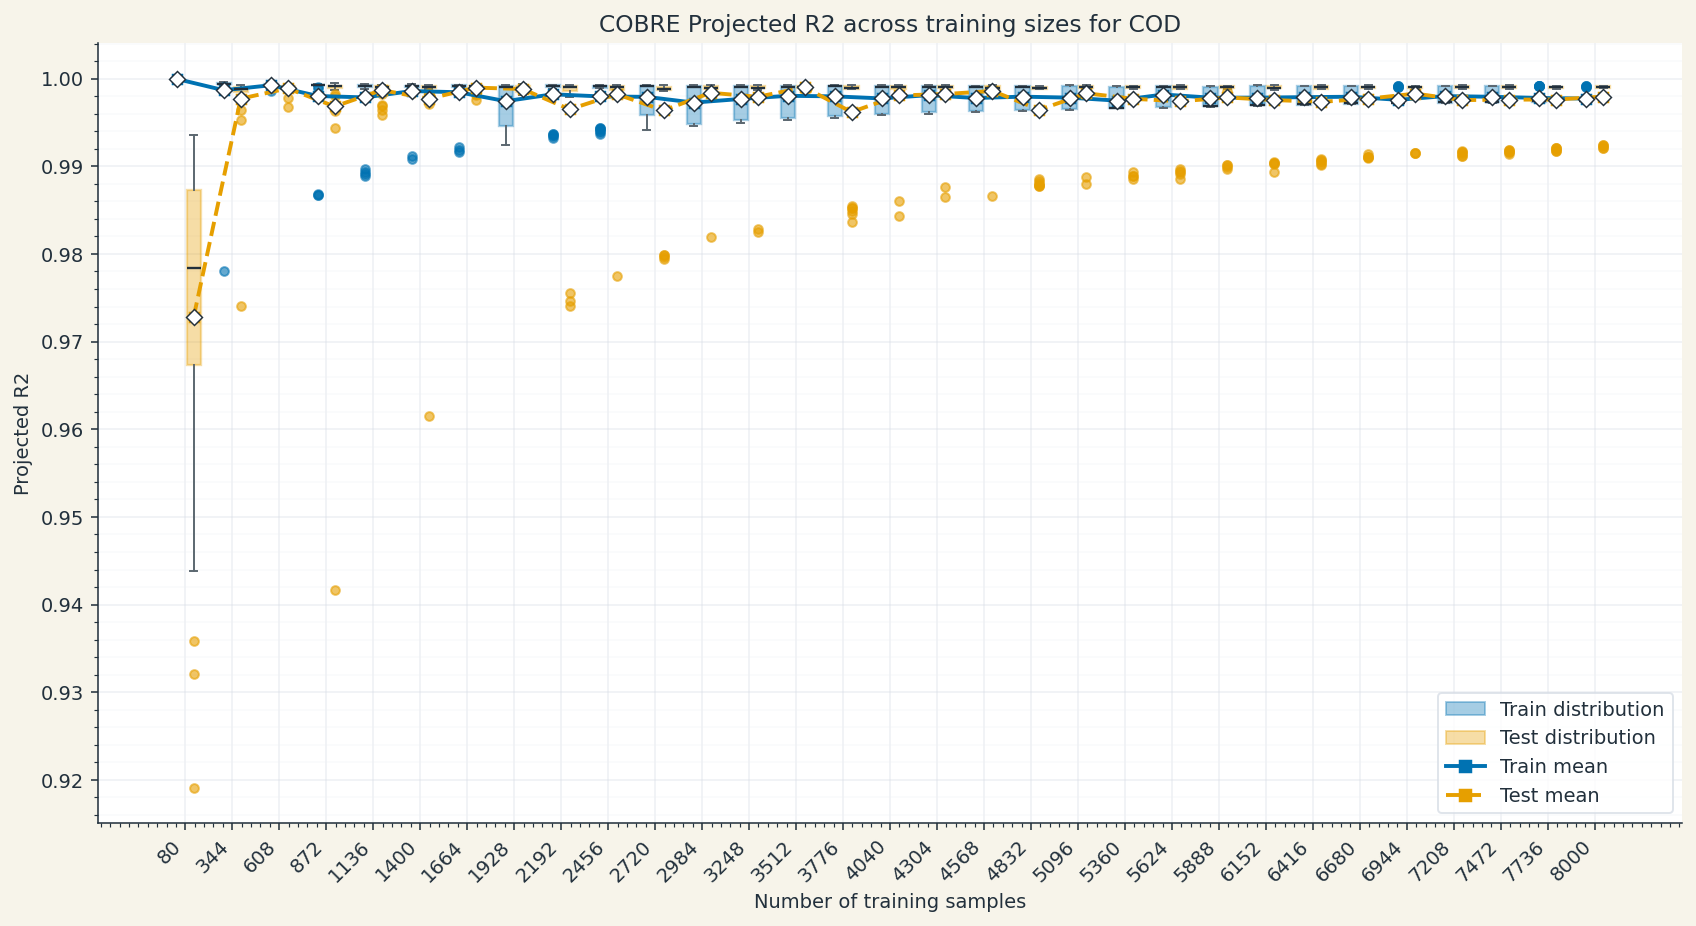

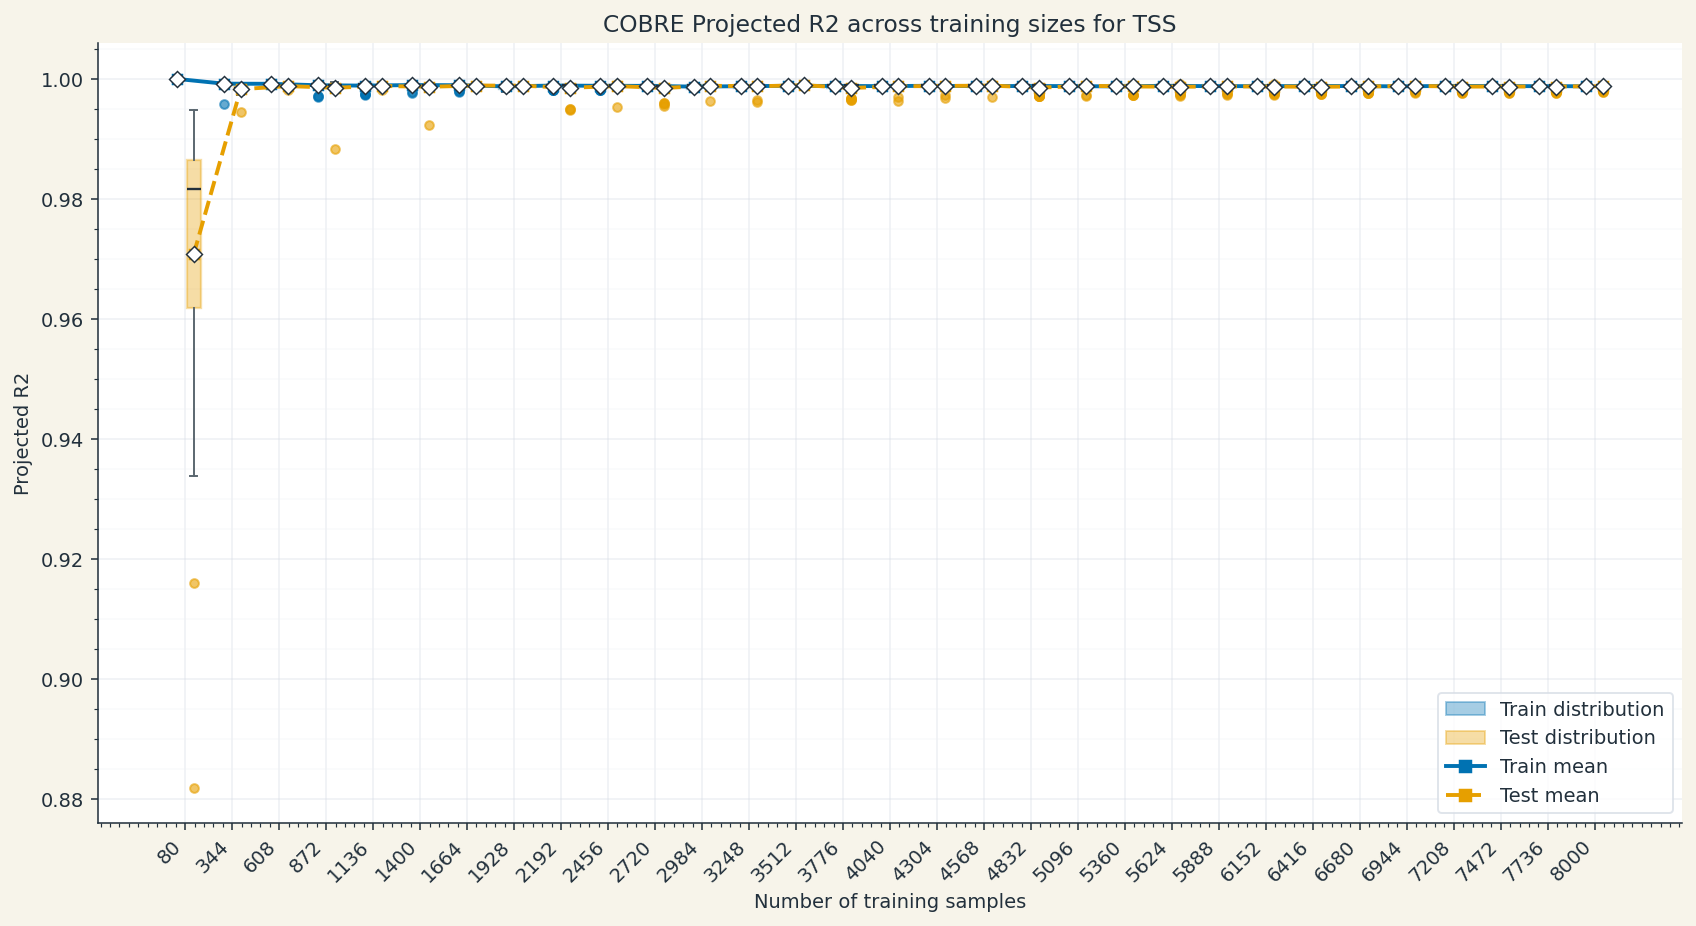

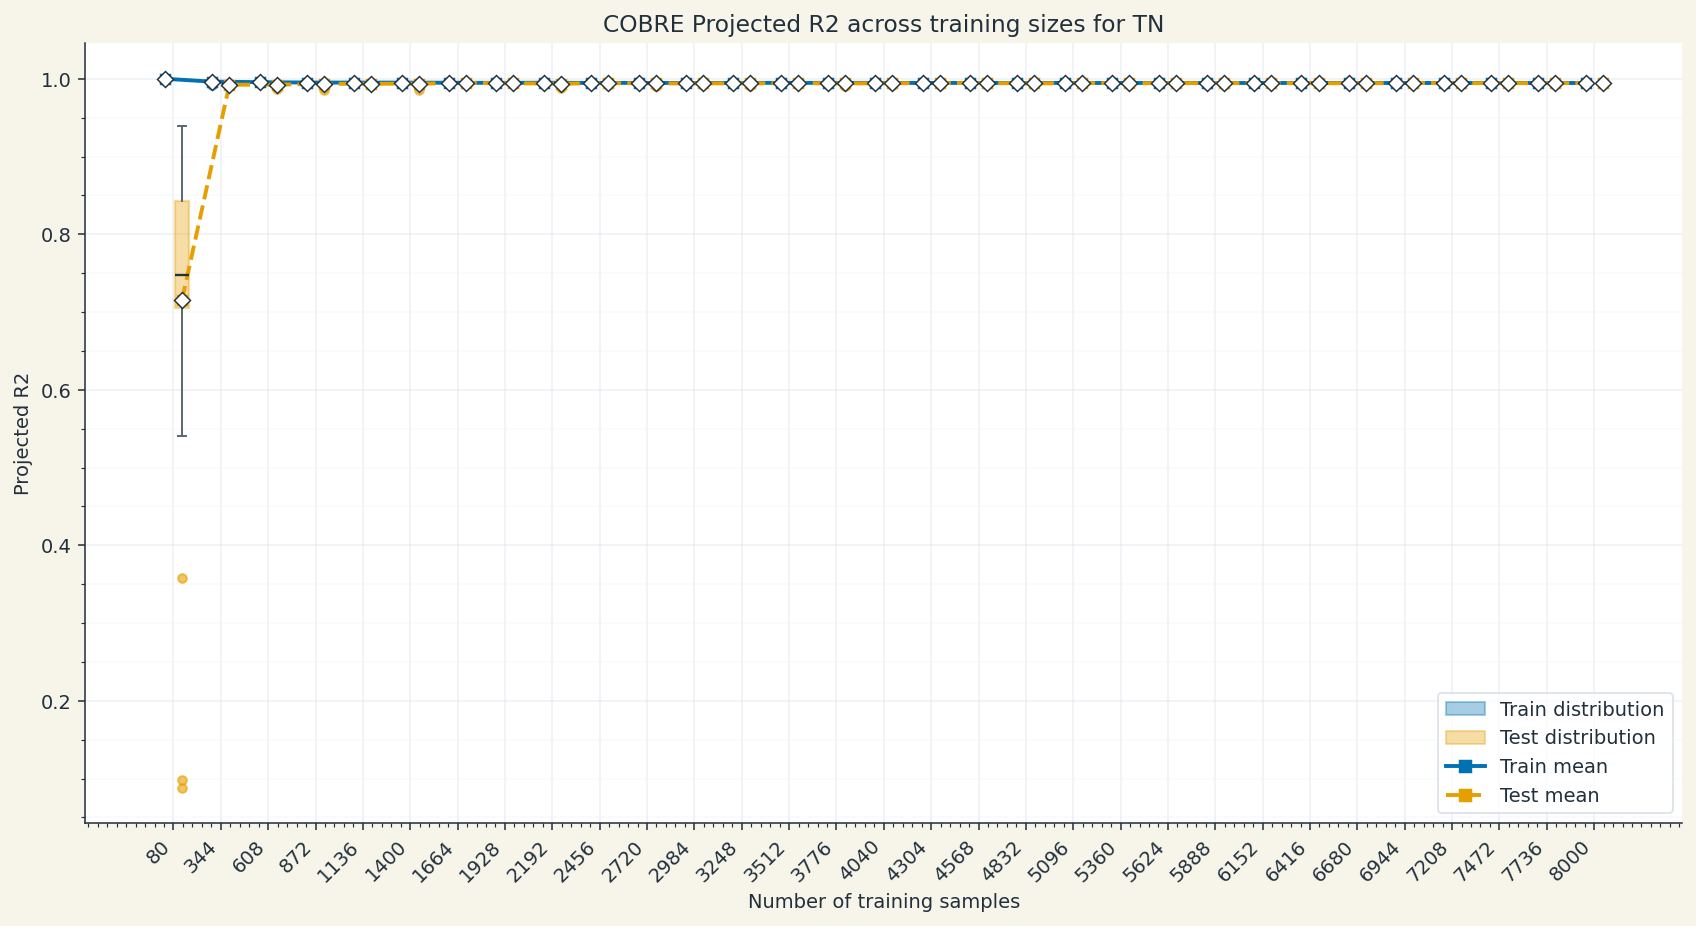

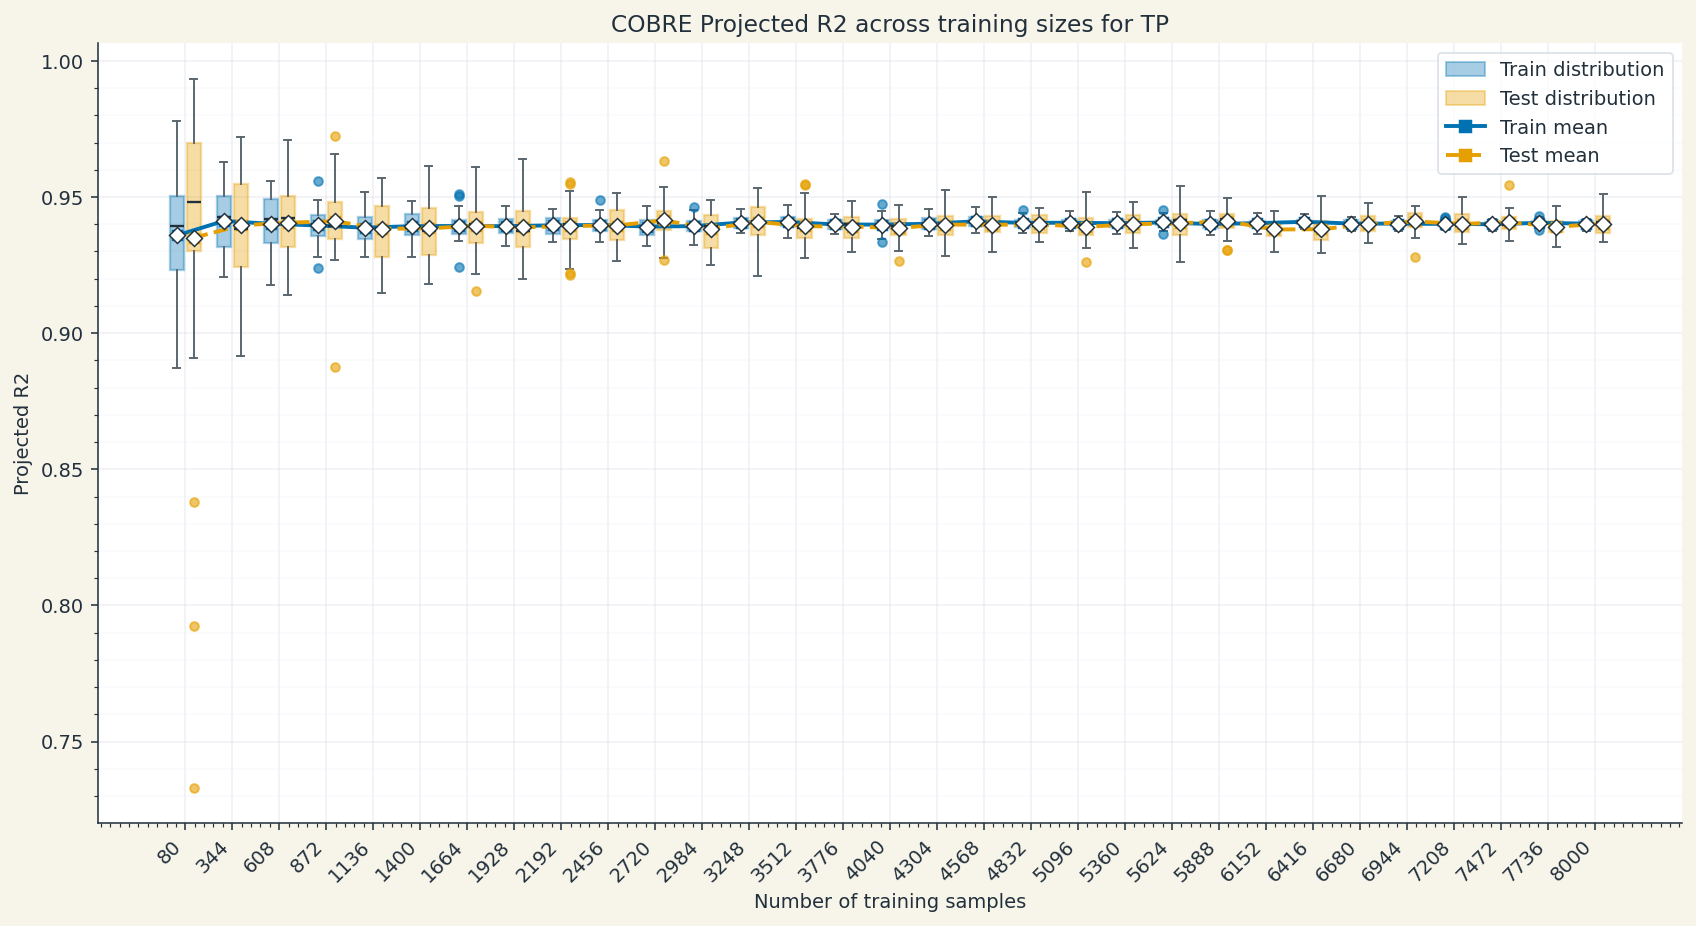

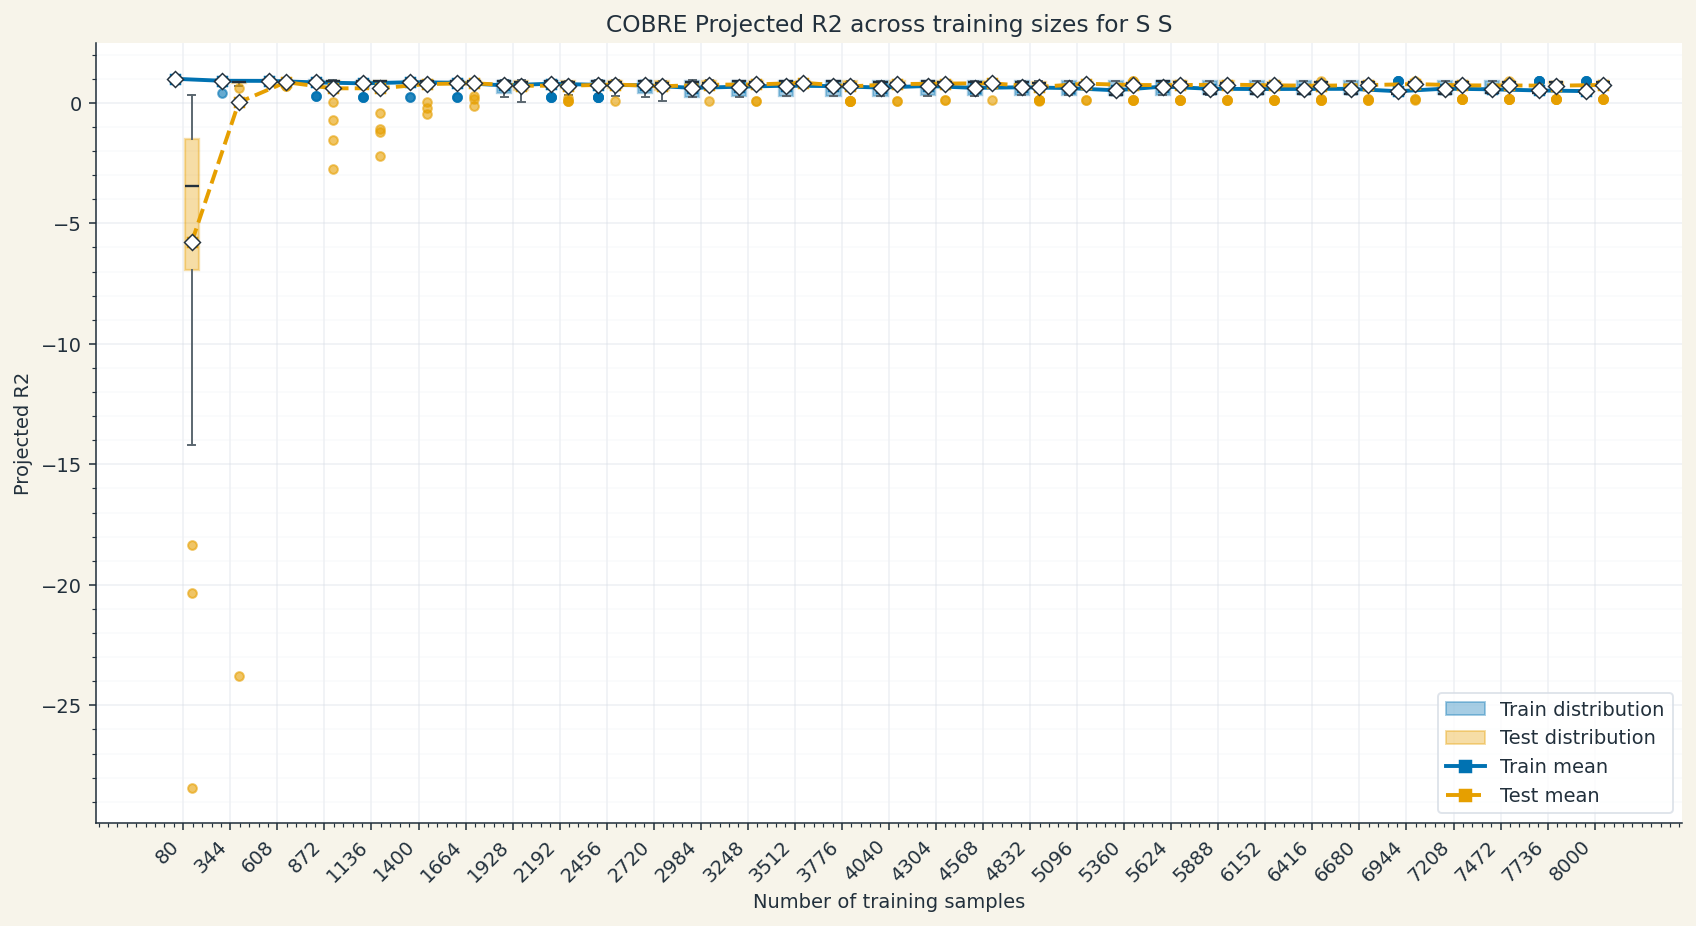

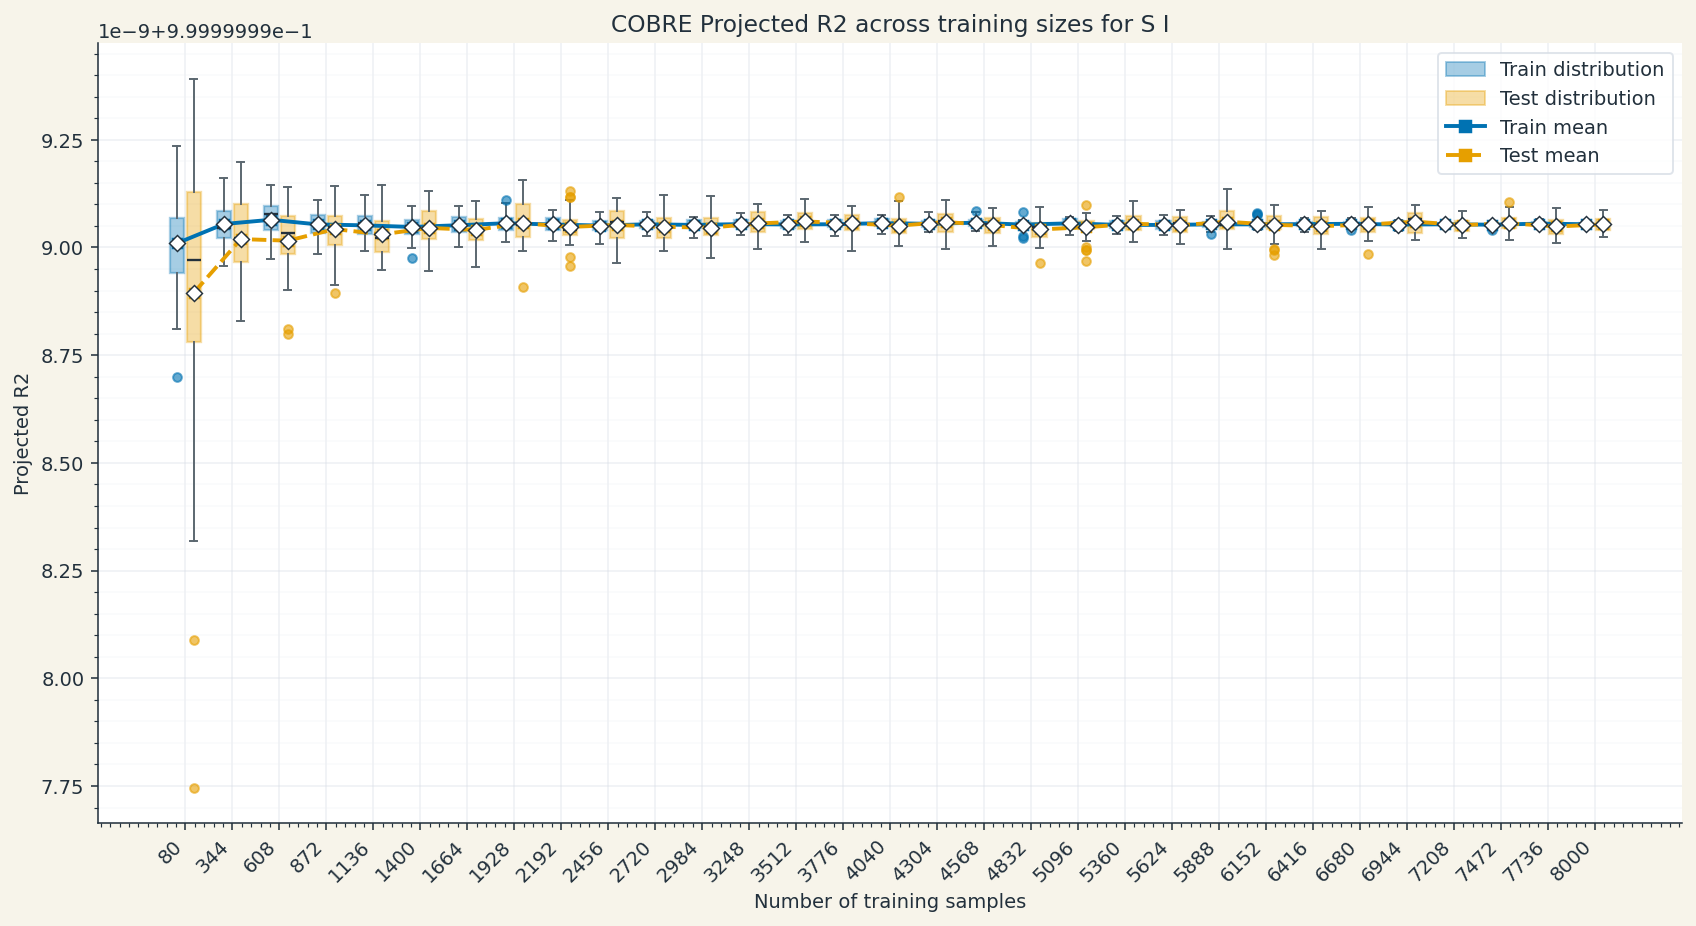

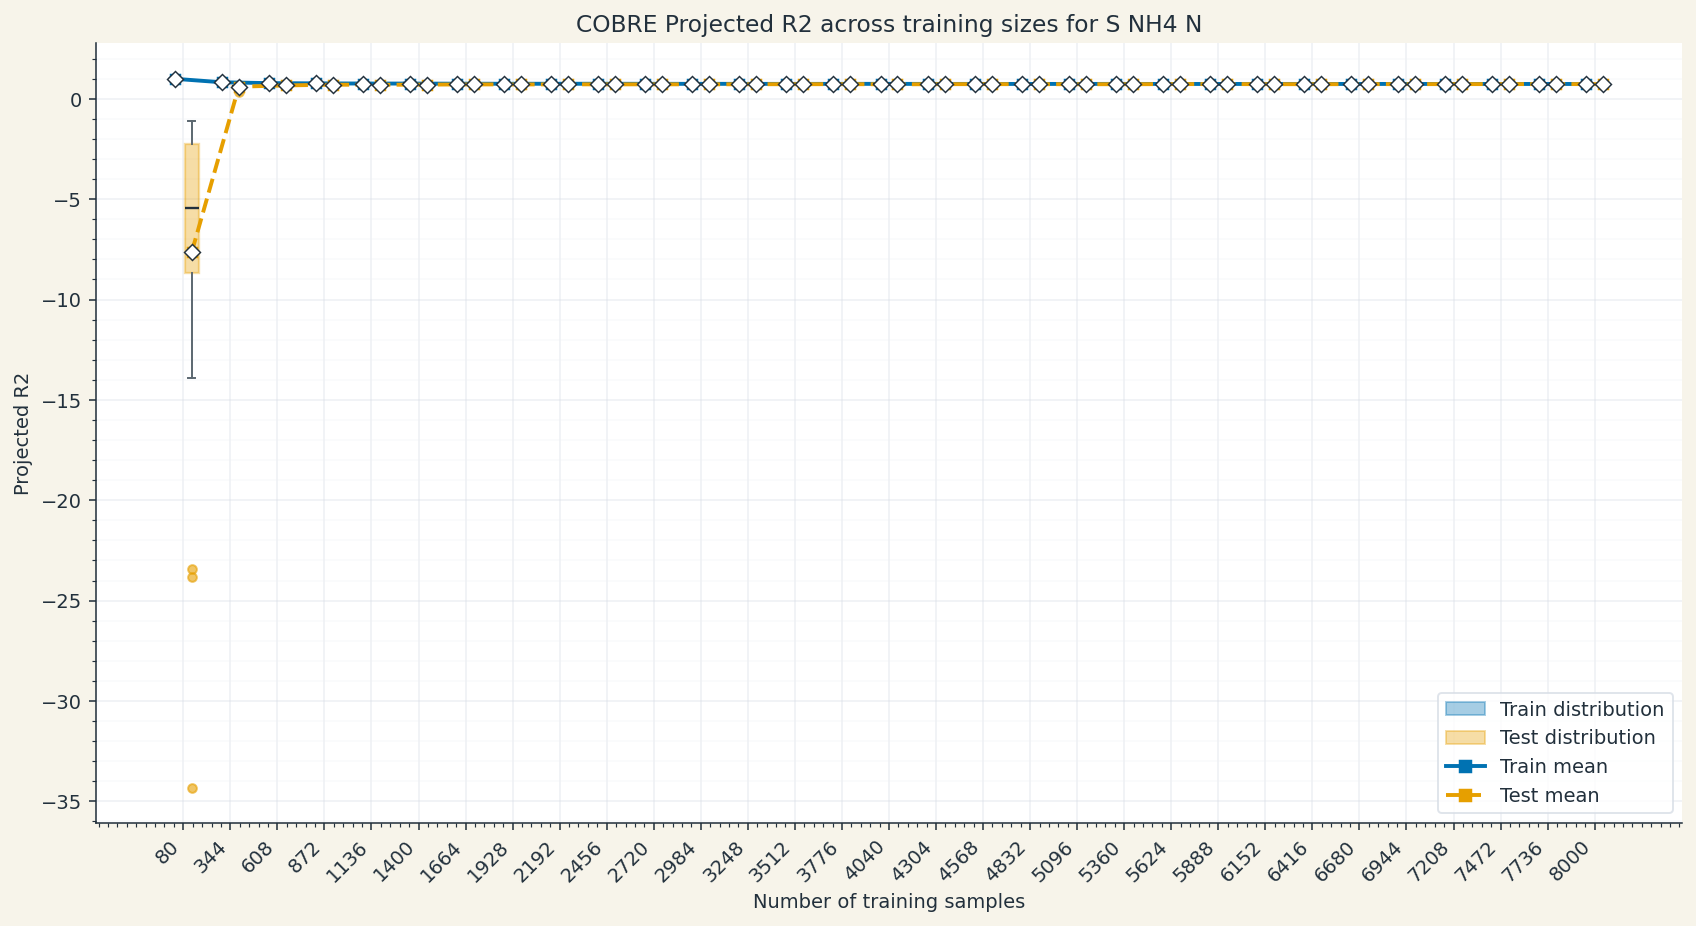

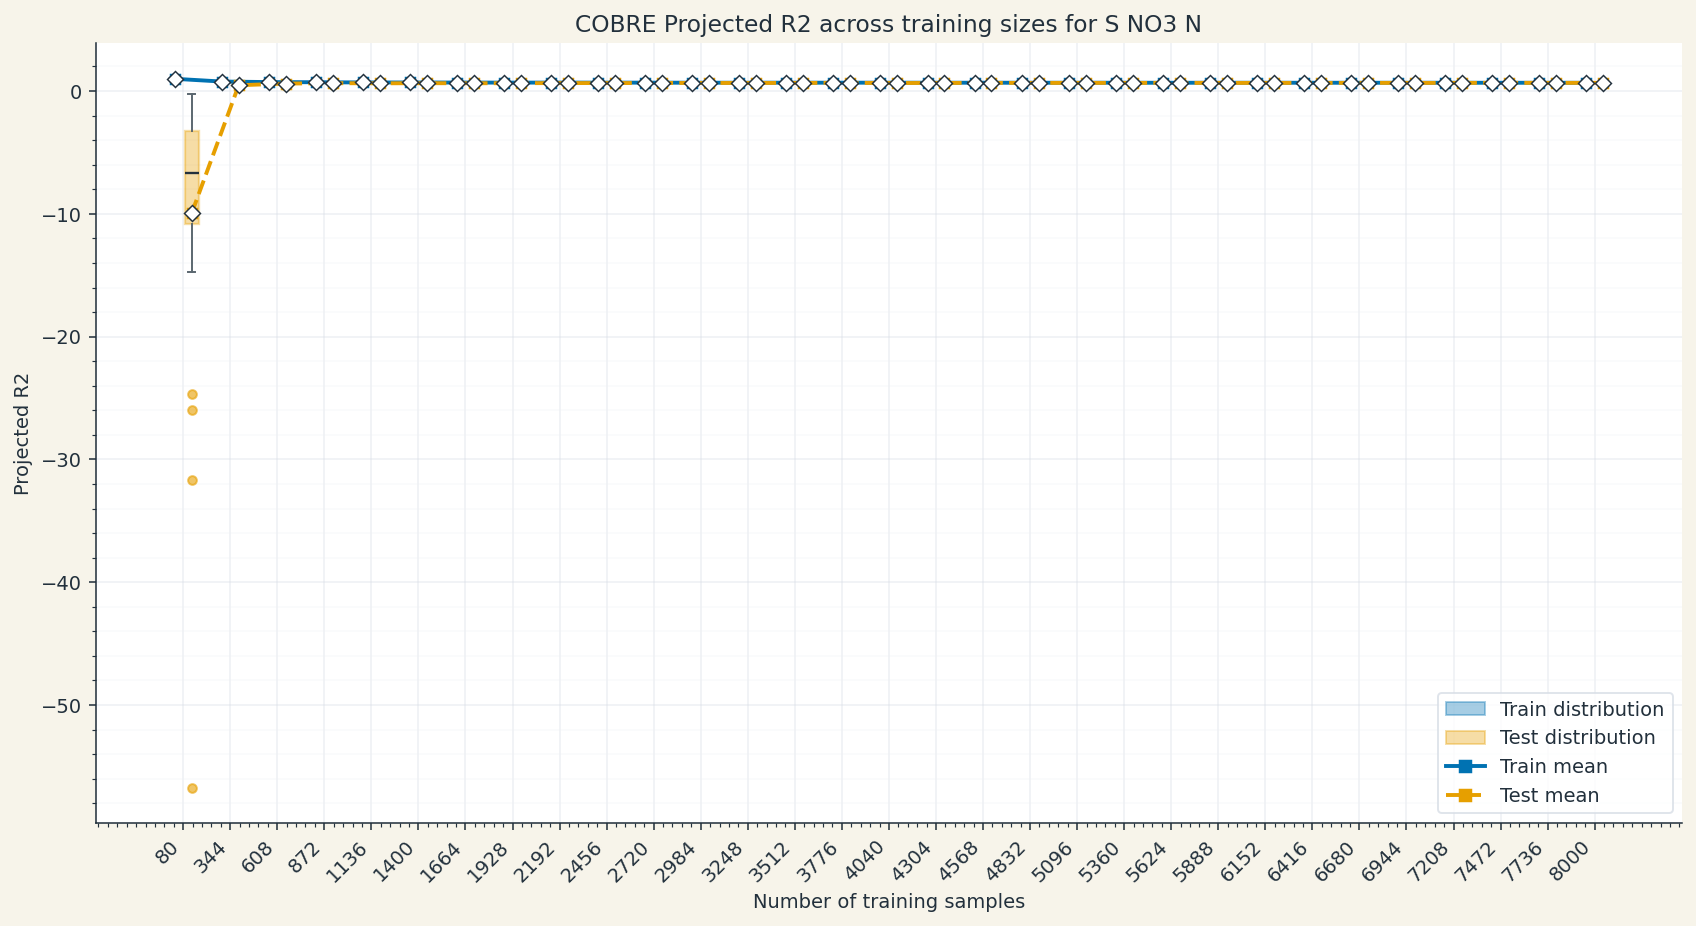

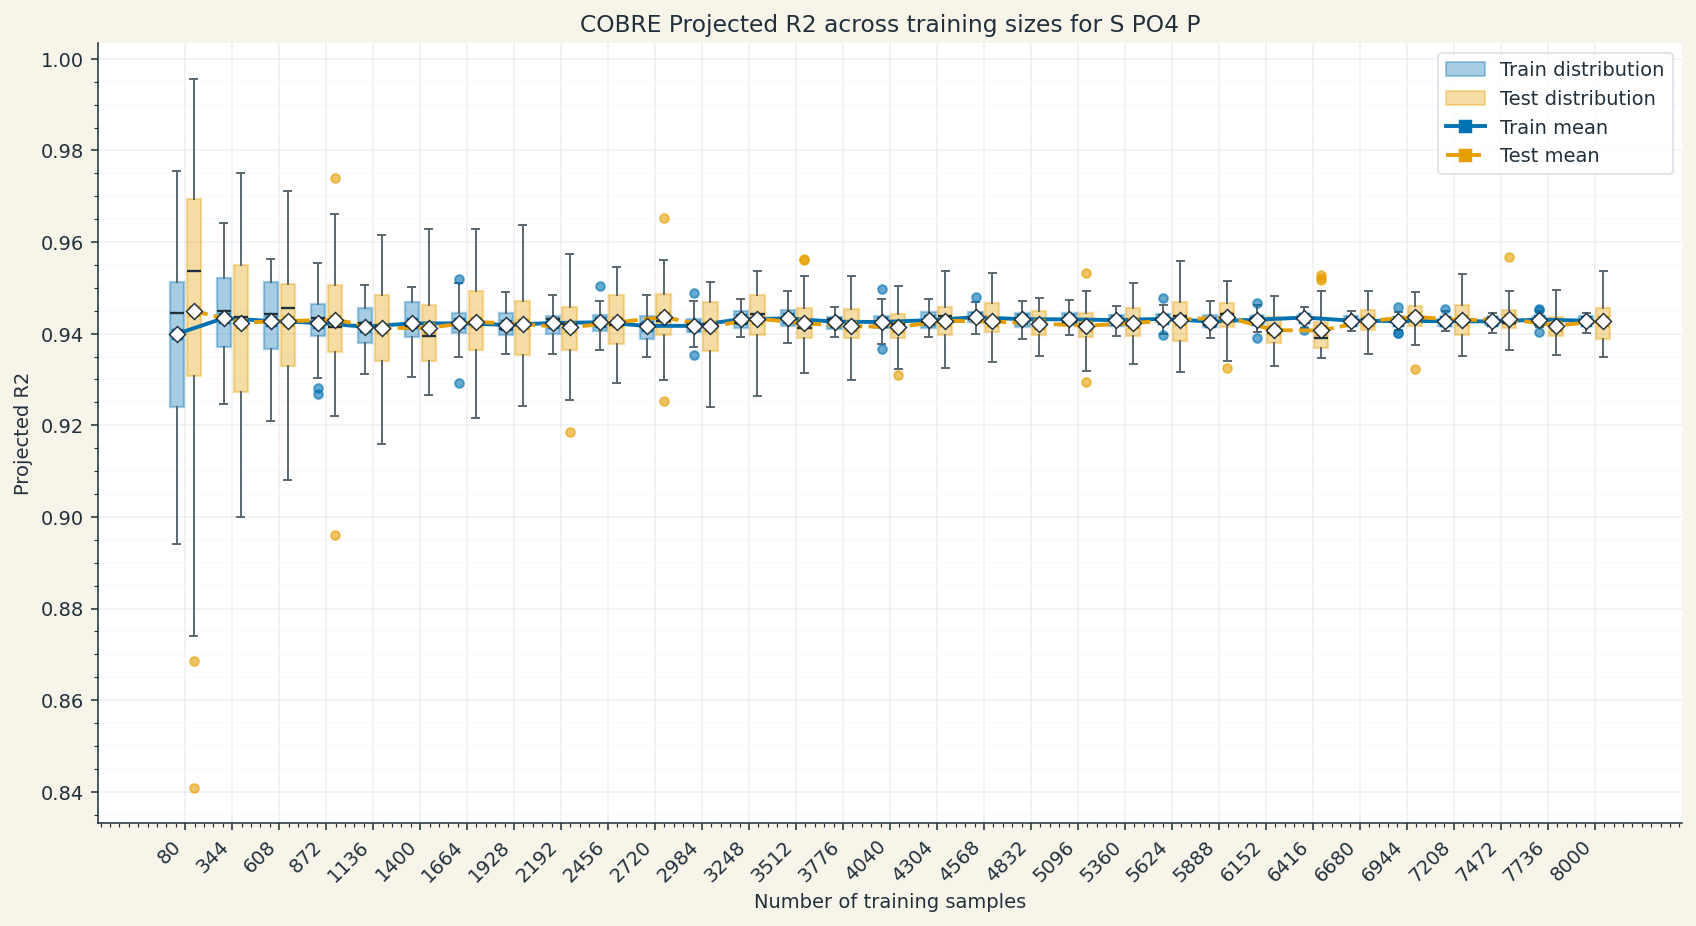

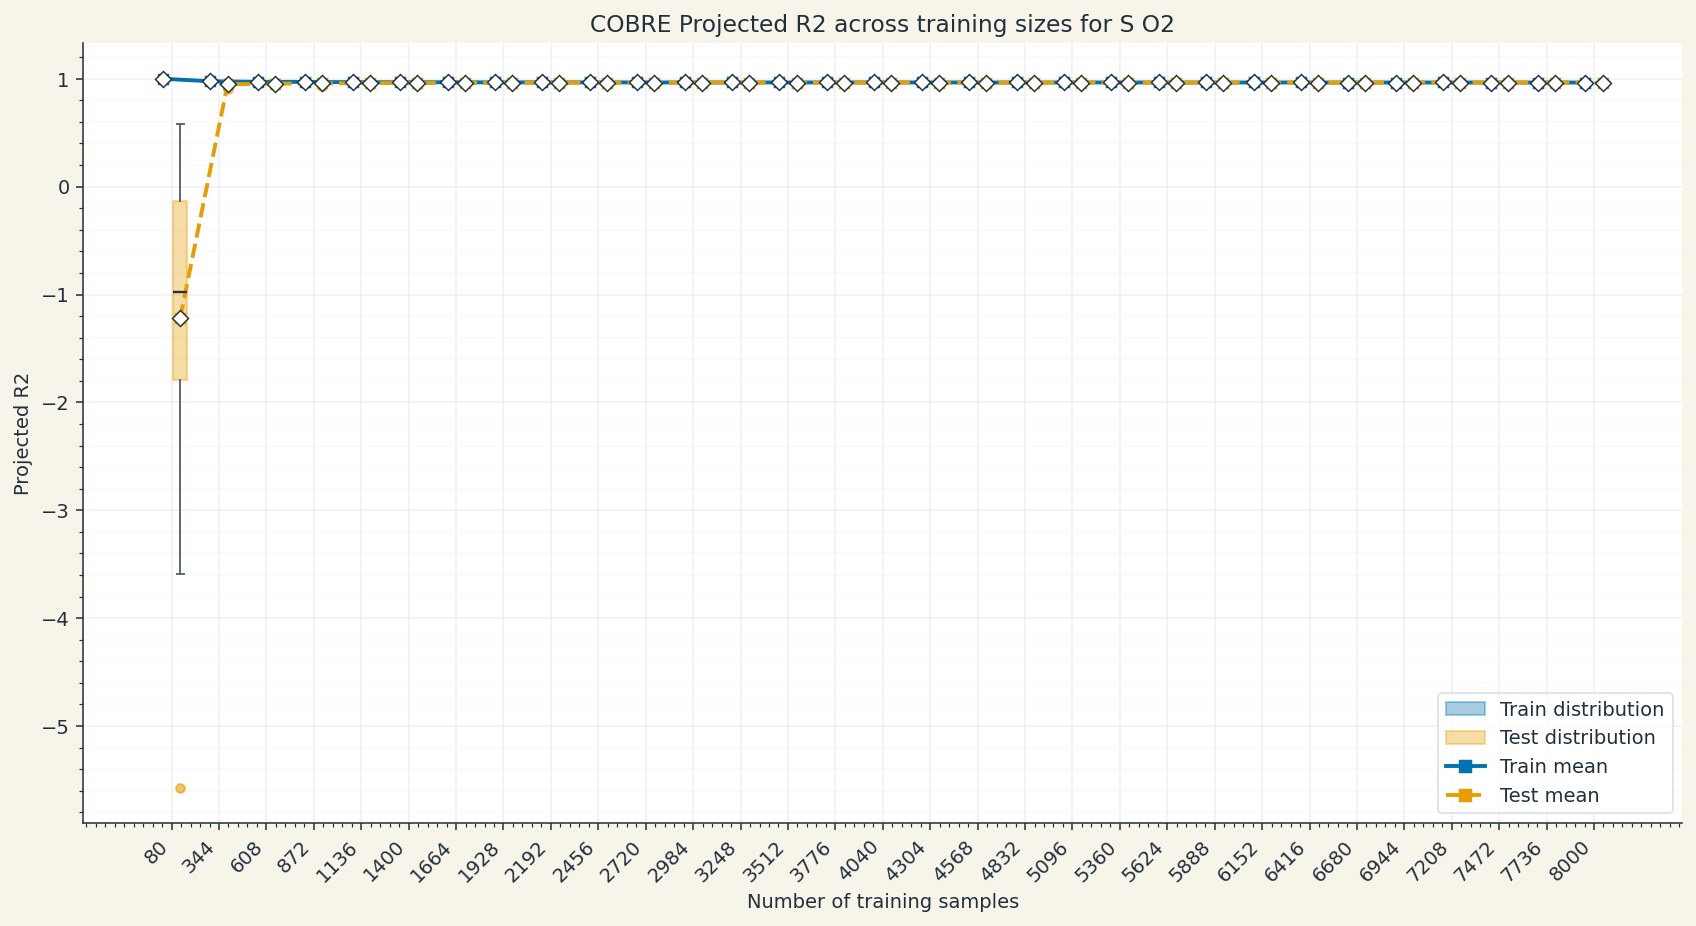

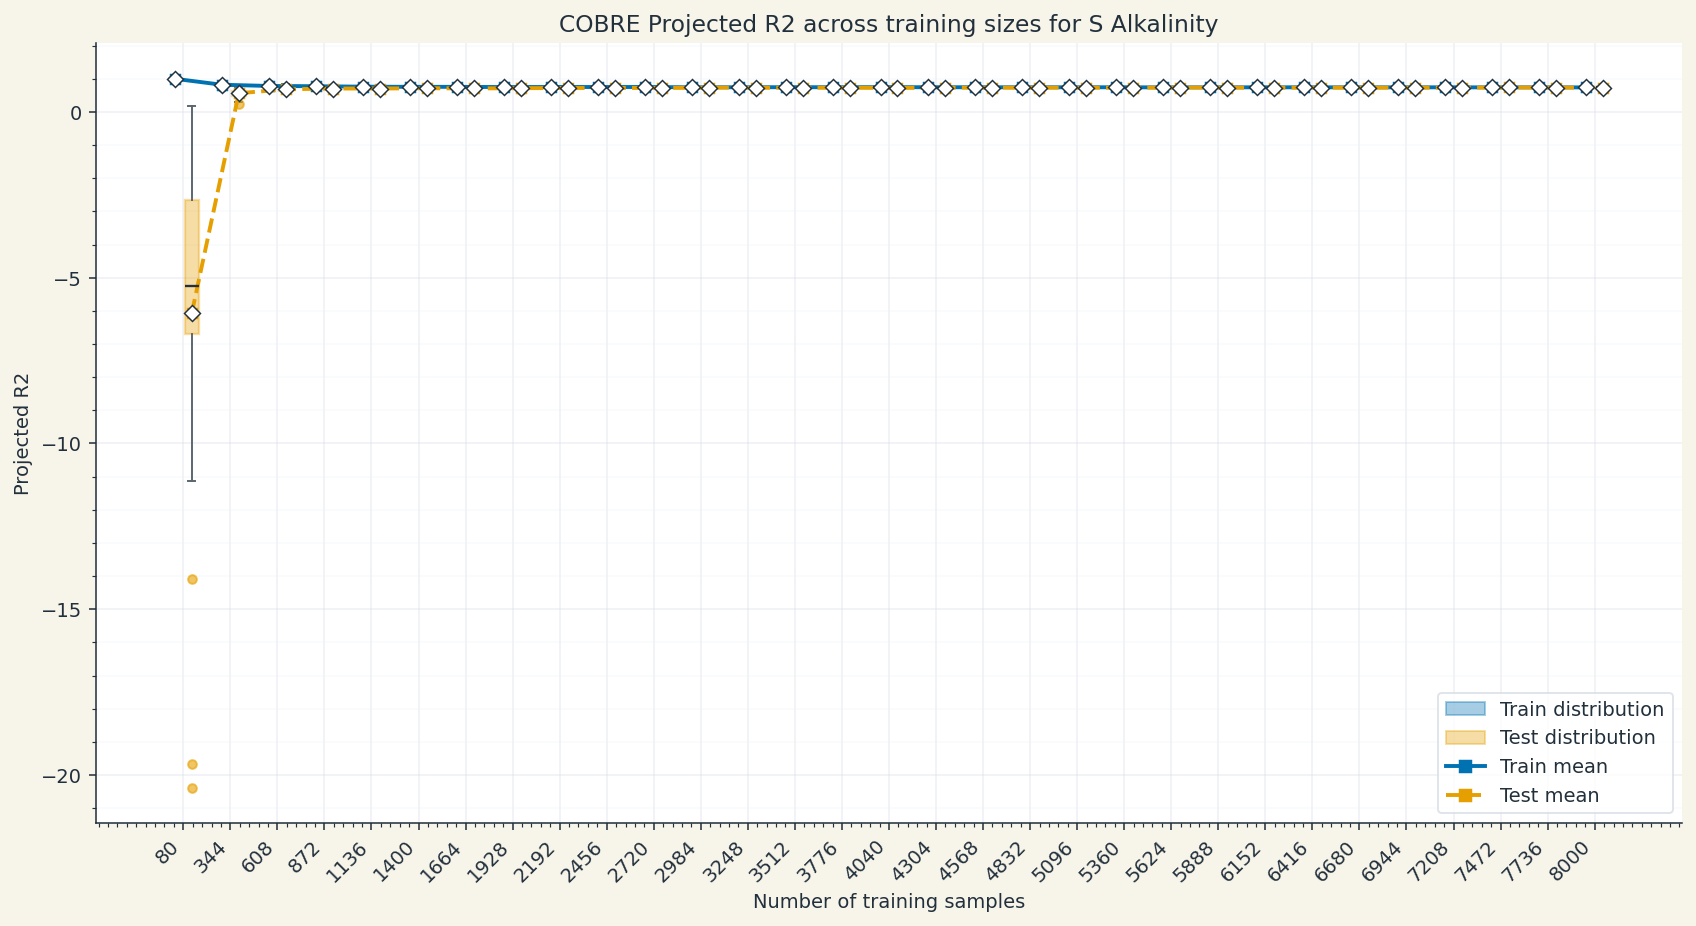

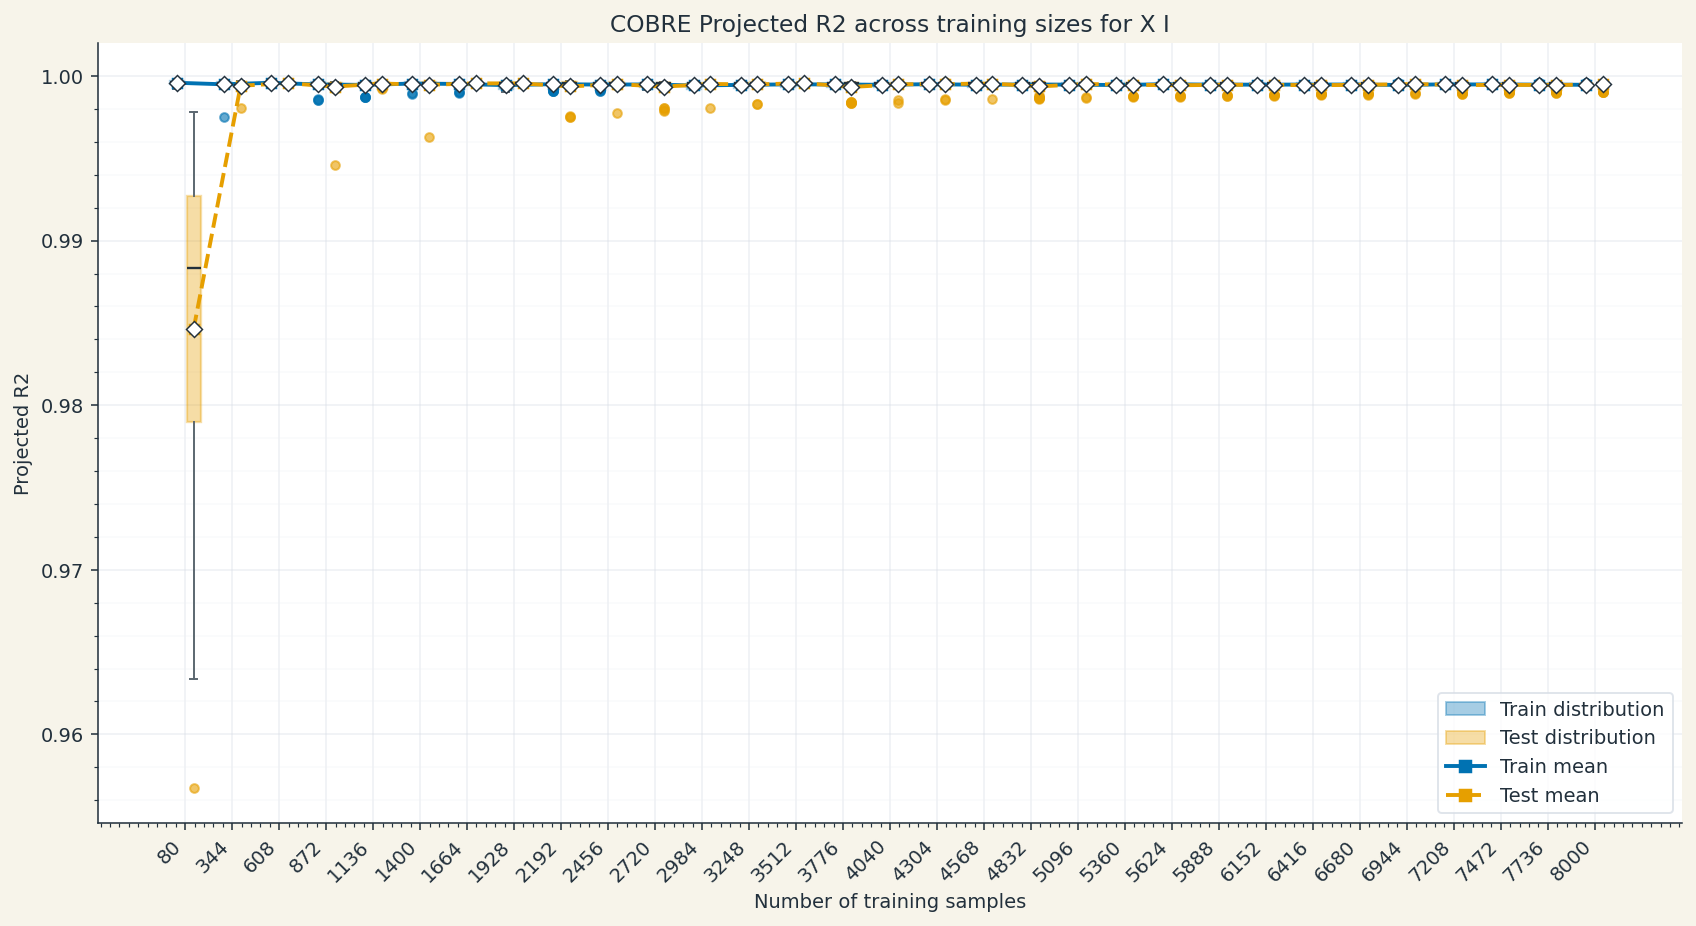

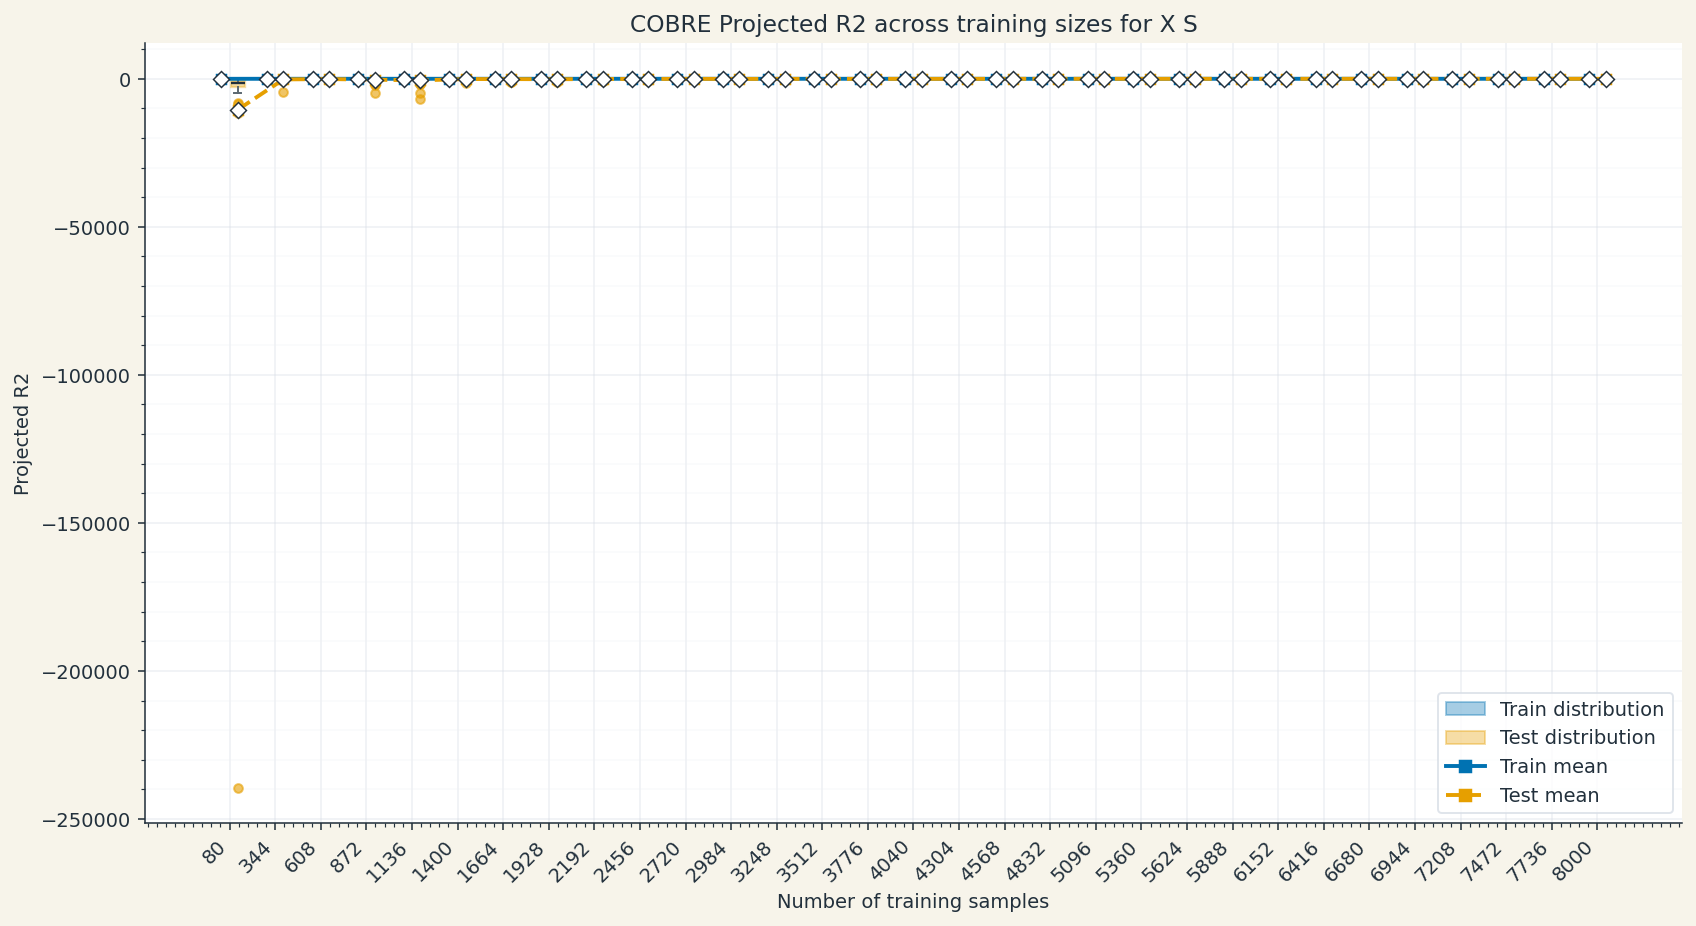

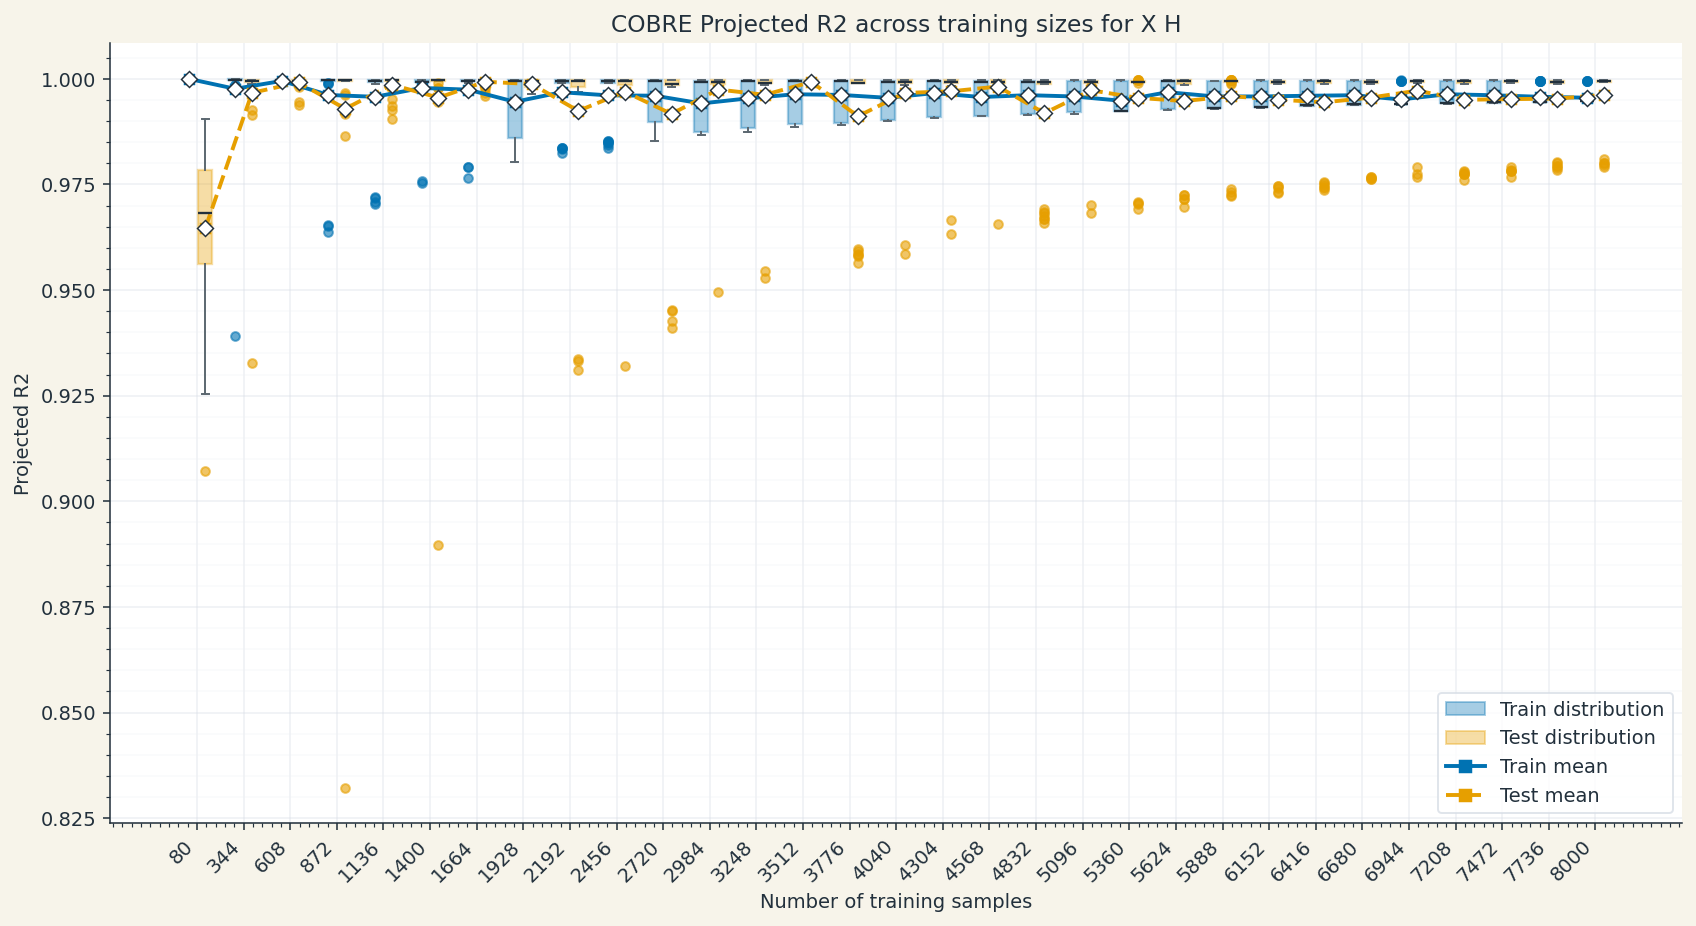

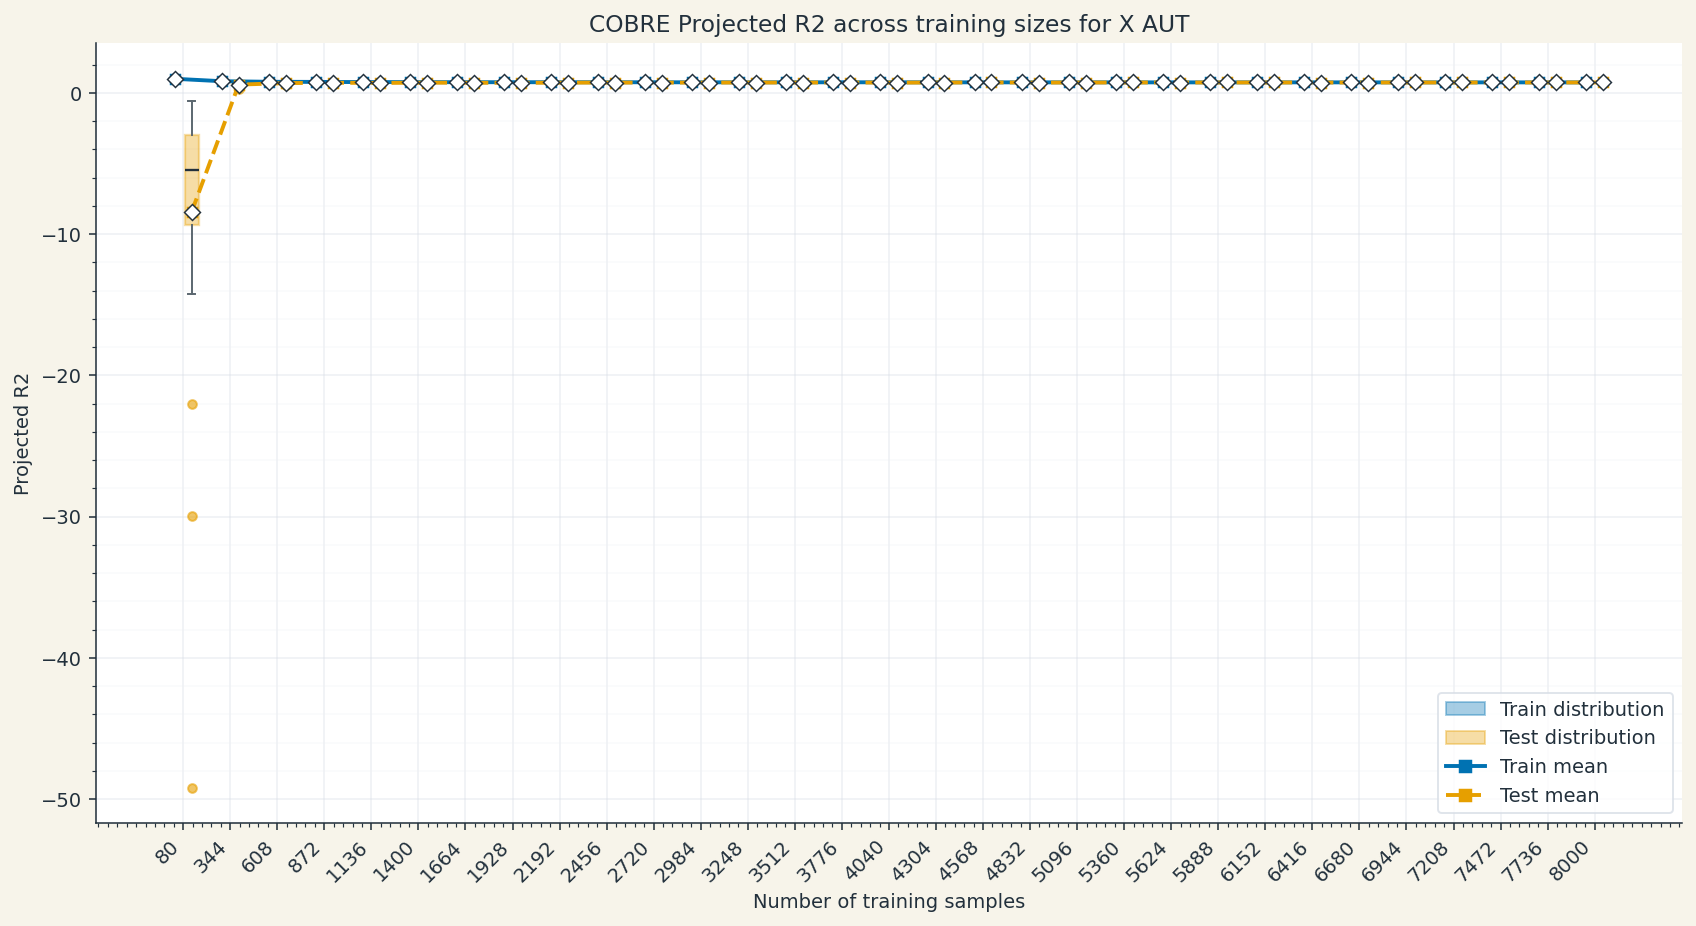

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_cobre_params, run_cobre_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))

cobre_analysis_params = load_cobre_params()
cobre_previous_result = globals().get("cobre_result")
cobre_analysis_hyperparameters = (
    dict(cobre_previous_result["best_hyperparameters"])
    if cobre_previous_result is not None
    else dict(cobre_analysis_params["training_defaults"])
)

cobre_analysis_result = run_model_dataset_size_analysis(
    "cobre",
    cobre_dataset,
    cobre_A_matrix,
    run_cobre_pipeline,
    model_params=cobre_analysis_params,
    model_hyperparameters=cobre_analysis_hyperparameters,
    persist_artifacts=False,
    extra_runner_kwargs={"composition_matrix": composition_matrix},
    **analysis_overrides,
)

print("COBRE analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(cobre_analysis_result['prediction_tables'])}")
display(pd.DataFrame([cobre_analysis_result["analysis_config"]]))
display(cobre_analysis_result["run_metadata"].head())

for target_name in cobre_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        cobre_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="COBRE",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_xgboost_regressor_params, run_xgboost_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

xgboost_analysis_params = load_xgboost_regressor_params()
xgboost_previous_result = classical_results.get("xgboost_regressor")
xgboost_analysis_hyperparameters = (
    dict(xgboost_previous_result["best_hyperparameters"])
    if xgboost_previous_result is not None
    else dict(xgboost_analysis_params["training_defaults"])
 )

xgboost_analysis_result = run_model_dataset_size_analysis(
    "xgboost_regressor",
    measured_dataset,
    A_matrix,
    run_xgboost_regressor_pipeline,
    model_params=xgboost_analysis_params,
    model_hyperparameters=xgboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("XGBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(xgboost_analysis_result['prediction_tables'])}")
display(pd.DataFrame([xgboost_analysis_result["analysis_config"]]))
display(xgboost_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        xgboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="XGBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_lightgbm_regressor_params, run_lightgbm_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

lightgbm_analysis_params = load_lightgbm_regressor_params()
lightgbm_previous_result = classical_results.get("lightgbm_regressor")
lightgbm_analysis_hyperparameters = (
    dict(lightgbm_previous_result["best_hyperparameters"])
    if lightgbm_previous_result is not None
    else dict(lightgbm_analysis_params["training_defaults"])
 )

lightgbm_analysis_result = run_model_dataset_size_analysis(
    "lightgbm_regressor",
    measured_dataset,
    A_matrix,
    run_lightgbm_regressor_pipeline,
    model_params=lightgbm_analysis_params,
    model_hyperparameters=lightgbm_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("LightGBM analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(lightgbm_analysis_result['prediction_tables'])}")
display(pd.DataFrame([lightgbm_analysis_result["analysis_config"]]))
display(lightgbm_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        lightgbm_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="LightGBM Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_catboost_regressor_params, run_catboost_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

catboost_analysis_params = load_catboost_regressor_params()
catboost_previous_result = classical_results.get("catboost_regressor")
catboost_analysis_hyperparameters = (
    dict(catboost_previous_result["best_hyperparameters"])
    if catboost_previous_result is not None
    else dict(catboost_analysis_params["training_defaults"])
 )

catboost_analysis_result = run_model_dataset_size_analysis(
    "catboost_regressor",
    measured_dataset,
    A_matrix,
    run_catboost_regressor_pipeline,
    model_params=catboost_analysis_params,
    model_hyperparameters=catboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("CatBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(catboost_analysis_result['prediction_tables'])}")
display(pd.DataFrame([catboost_analysis_result["analysis_config"]]))
display(catboost_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        catboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="CatBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_adaboost_regressor_params, run_adaboost_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

adaboost_analysis_params = load_adaboost_regressor_params()
adaboost_previous_result = classical_results.get("adaboost_regressor")
adaboost_analysis_hyperparameters = (
    dict(adaboost_previous_result["best_hyperparameters"])
    if adaboost_previous_result is not None
    else dict(adaboost_analysis_params["training_defaults"])
 )

adaboost_analysis_result = run_model_dataset_size_analysis(
    "adaboost_regressor",
    measured_dataset,
    A_matrix,
    run_adaboost_regressor_pipeline,
    model_params=adaboost_analysis_params,
    model_hyperparameters=adaboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("AdaBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(adaboost_analysis_result['prediction_tables'])}")
display(pd.DataFrame([adaboost_analysis_result["analysis_config"]]))
display(adaboost_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        adaboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="AdaBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_random_forest_regressor_params, run_random_forest_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

random_forest_analysis_params = load_random_forest_regressor_params()
random_forest_previous_result = classical_results.get("random_forest_regressor")
random_forest_analysis_hyperparameters = (
    dict(random_forest_previous_result["best_hyperparameters"])
    if random_forest_previous_result is not None
    else dict(random_forest_analysis_params["training_defaults"])
 )

random_forest_analysis_result = run_model_dataset_size_analysis(
    "random_forest_regressor",
    measured_dataset,
    A_matrix,
    run_random_forest_regressor_pipeline,
    model_params=random_forest_analysis_params,
    model_hyperparameters=random_forest_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("Random forest analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(random_forest_analysis_result['prediction_tables'])}")
display(pd.DataFrame([random_forest_analysis_result["analysis_config"]]))
display(random_forest_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        random_forest_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="Random Forest Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_svr_regressor_params, run_svr_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

svr_analysis_params = load_svr_regressor_params()
svr_previous_result = classical_results.get("svr_regressor")
svr_analysis_hyperparameters = (
    dict(svr_previous_result["best_hyperparameters"])
    if svr_previous_result is not None
    else dict(svr_analysis_params["training_defaults"])
 )

svr_analysis_result = run_model_dataset_size_analysis(
    "svr_regressor",
    measured_dataset,
    A_matrix,
    run_svr_regressor_pipeline,
    model_params=svr_analysis_params,
    model_hyperparameters=svr_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("SVR analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(svr_analysis_result['prediction_tables'])}")
display(pd.DataFrame([svr_analysis_result["analysis_config"]]))
display(svr_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        svr_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="SVR Regressor",
    )
    display(figure)
    plt.close(figure)